# ID of machine learning potential
Here you can find an example ID of a trained machine learning potential, with information on the dataset and on its validation / performance.

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read, write
from collections import Counter
import os
import yaml
from mlputils.benchmark import energy_levels_crossings, get_calc

In [2]:
#settings and file paths - choose the ones you need
element = 'Cu'
folder  = '/Users/ginardi/Desktop/science/55Ry/Cu/cnap/cnap_2.984/update_hole/'
benchmark_file = 'flare_lammps_benchmark.yaml'
trainset_file  = 'train.xyz'
testset_file   = 'test.xyz' 
err_style      = 'mae'
calc_config    = {'calculator': 'flare_lammps',
                  'model_file': f'{folder}lmp.flare'}

#read / load data
with open(folder+benchmark_file,'r') as f:
    benchmarks = yaml.safe_load(f)

train = read(folder+trainset_file, index=':')
test  = read(folder+testset_file, index=':')

#get a potential calculator for quick last-minute in-place calculations
calc = get_calc(calc_config)

## (Optional) Training and test set analyisis

First, we need to split the database distinguishing bulk, slab models, and clusters. This is done here by looking at the number density of the configurations $N/V$, where $N$ is the number of atoms and $V$ is the volume of the cell. Due to the vacuum required to avoid spurious self-interaction in DFT calculations, generally slabs and clusters are less number-dense than bulk and the three categories lie on well separated ranges. This way, you can split the dataset in these categories by manually adjusting thresholds for number densities.

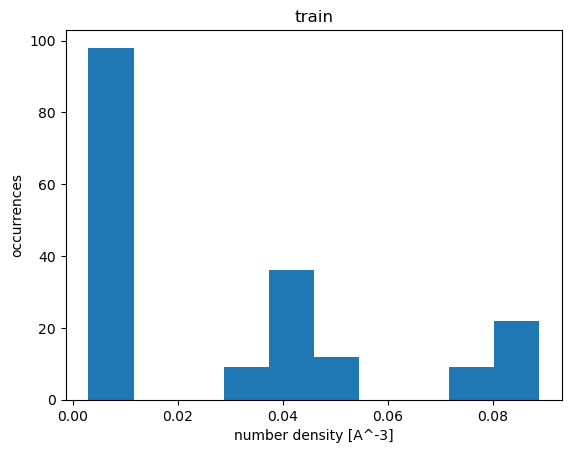

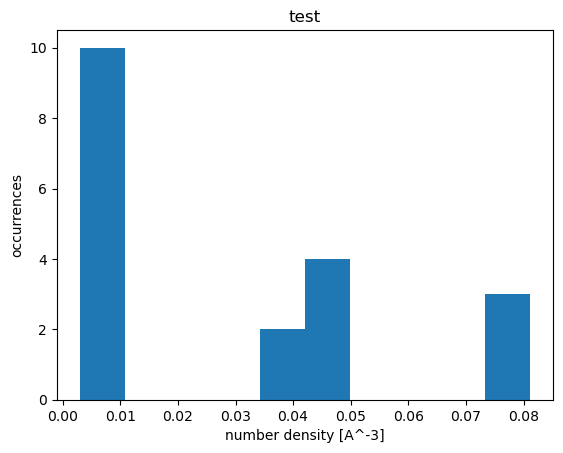

In [3]:
#split data here

def plot_densities(conf_set, title=''):

    number_densities = []
    for conf in conf_set:
        N = len(conf)
        vol = conf.cell.volume
        number_densities.append(N/vol)

    plt.figure()
    plt.hist(number_densities)
    plt.xlabel('number density [A^-3]')
    plt.ylabel('occurrences')
    plt.title(title)
    #plt.show()

    return number_densities

def split_per_density(conf_set, thr_clust, thr_surf):

    number_densities = [len(atoms)/atoms.cell.volume for atoms in conf_set]

    bulk     = [atoms for atoms, d in zip(conf_set, number_densities) if d>thr_surf]
    surf     = [atoms for atoms, d in zip(conf_set, number_densities) if d<thr_surf and d>thr_clust]
    clusters = [atoms for atoms, d in zip(conf_set, number_densities) if d<thr_clust]

    return bulk, surf, clusters

#plot and eyecheck to get thresholds
d = plot_densities(train, title='train')
d = plot_densities(test, title='test')

#manually set these to split the dataset
thr_clust = 0.02
thr_surf  = 0.06

#split sets in bulk, surf, clusters
bulk_train, surf_train, clust_train = split_per_density(train, thr_clust, thr_surf)
bulk_test, surf_test, clust_test    = split_per_density(test, thr_clust, thr_surf)

In [4]:
output_folder = 'database_postprocessing/'
os.makedirs(folder+output_folder, exist_ok=True)

write(folder+output_folder+'fammivedere.xyz', clust_train)

btrc = Counter(len(atoms) for atoms in bulk_train)
strc = Counter(len(atoms) for atoms in surf_train)
ctrc = Counter(len(atoms) for atoms in clust_train)
btec = Counter(len(atoms) for atoms in bulk_test)
stec = Counter(len(atoms) for atoms in surf_test)
ctec = Counter(len(atoms) for atoms in clust_test)

#print the data
print('\n---------------')
print('---TRAIN SET---')
print('---------------\n')

print('Bulk')
print('--------------')

print(f'{len(bulk_train)} bulk files, of which')
for size in btrc.keys():
    print(f'size = {size} : {btrc[size]} configs')

print('Surfaces')
print('--------------')

print(f'{len(surf_train)} surf files, of which')
for size in strc.keys():
    print(f'size = {size} : {strc[size]} configs')

print('Clusters')
print('--------------')

print(f'{len(clust_train)} clusters files, of which')
for size in ctrc.keys():
    print(f'size = {size} : {ctrc[size]} configs')

print('\n--------------')
print('---TEST SET---')
print('--------------\n')

print('Bulk')
print('--------------')
print(f'{len(bulk_test)} bulk files, of which')
for size in btec.keys():
    print(f'size = {size} : {btec[size]} configs')

print('Surfaces')
print('--------------')
print(f'{len(surf_test)} surf files, of which')
for size in stec.keys():
    print(f'size = {size} : {stec[size]} configs')

print('Clusters')
print('--------------')
print(f'{len(clust_test)} clusters files, of which')
for size in ctec.keys():
    print(f'size = {size} : {ctec[size]} configs')


#write split files to eye-check
write(folder+output_folder+'bulk_train.xyz', bulk_train)
write(folder+output_folder+'surf_train.xyz', surf_train)
write(folder+output_folder+'clus_train.xyz', clust_train)

write(folder+output_folder+'bulk_test.xyz', bulk_test)
write(folder+output_folder+'surf_test.xyz', surf_test)
write(folder+output_folder+'clus_test.xyz', clust_test)


---------------
---TRAIN SET---
---------------

Bulk
--------------
31 bulk files, of which
size = 108 : 7 configs
size = 32 : 14 configs
size = 31 : 10 configs
Surfaces
--------------
57 surf files, of which
size = 80 : 4 configs
size = 63 : 47 configs
size = 54 : 5 configs
size = 112 : 1 configs
Clusters
--------------
98 clusters files, of which
size = 150 : 4 configs
size = 55 : 18 configs
size = 56 : 27 configs
size = 44 : 19 configs
size = 85 : 10 configs
size = 110 : 10 configs
size = 63 : 8 configs
size = 130 : 2 configs

--------------
---TEST SET---
--------------

Bulk
--------------
3 bulk files, of which
size = 32 : 2 configs
size = 31 : 1 configs
Surfaces
--------------
6 surf files, of which
size = 63 : 6 configs
Clusters
--------------
10 clusters files, of which
size = 55 : 3 configs
size = 56 : 3 configs
size = 44 : 3 configs
size = 110 : 1 configs


Let's plot some information about the dataset:

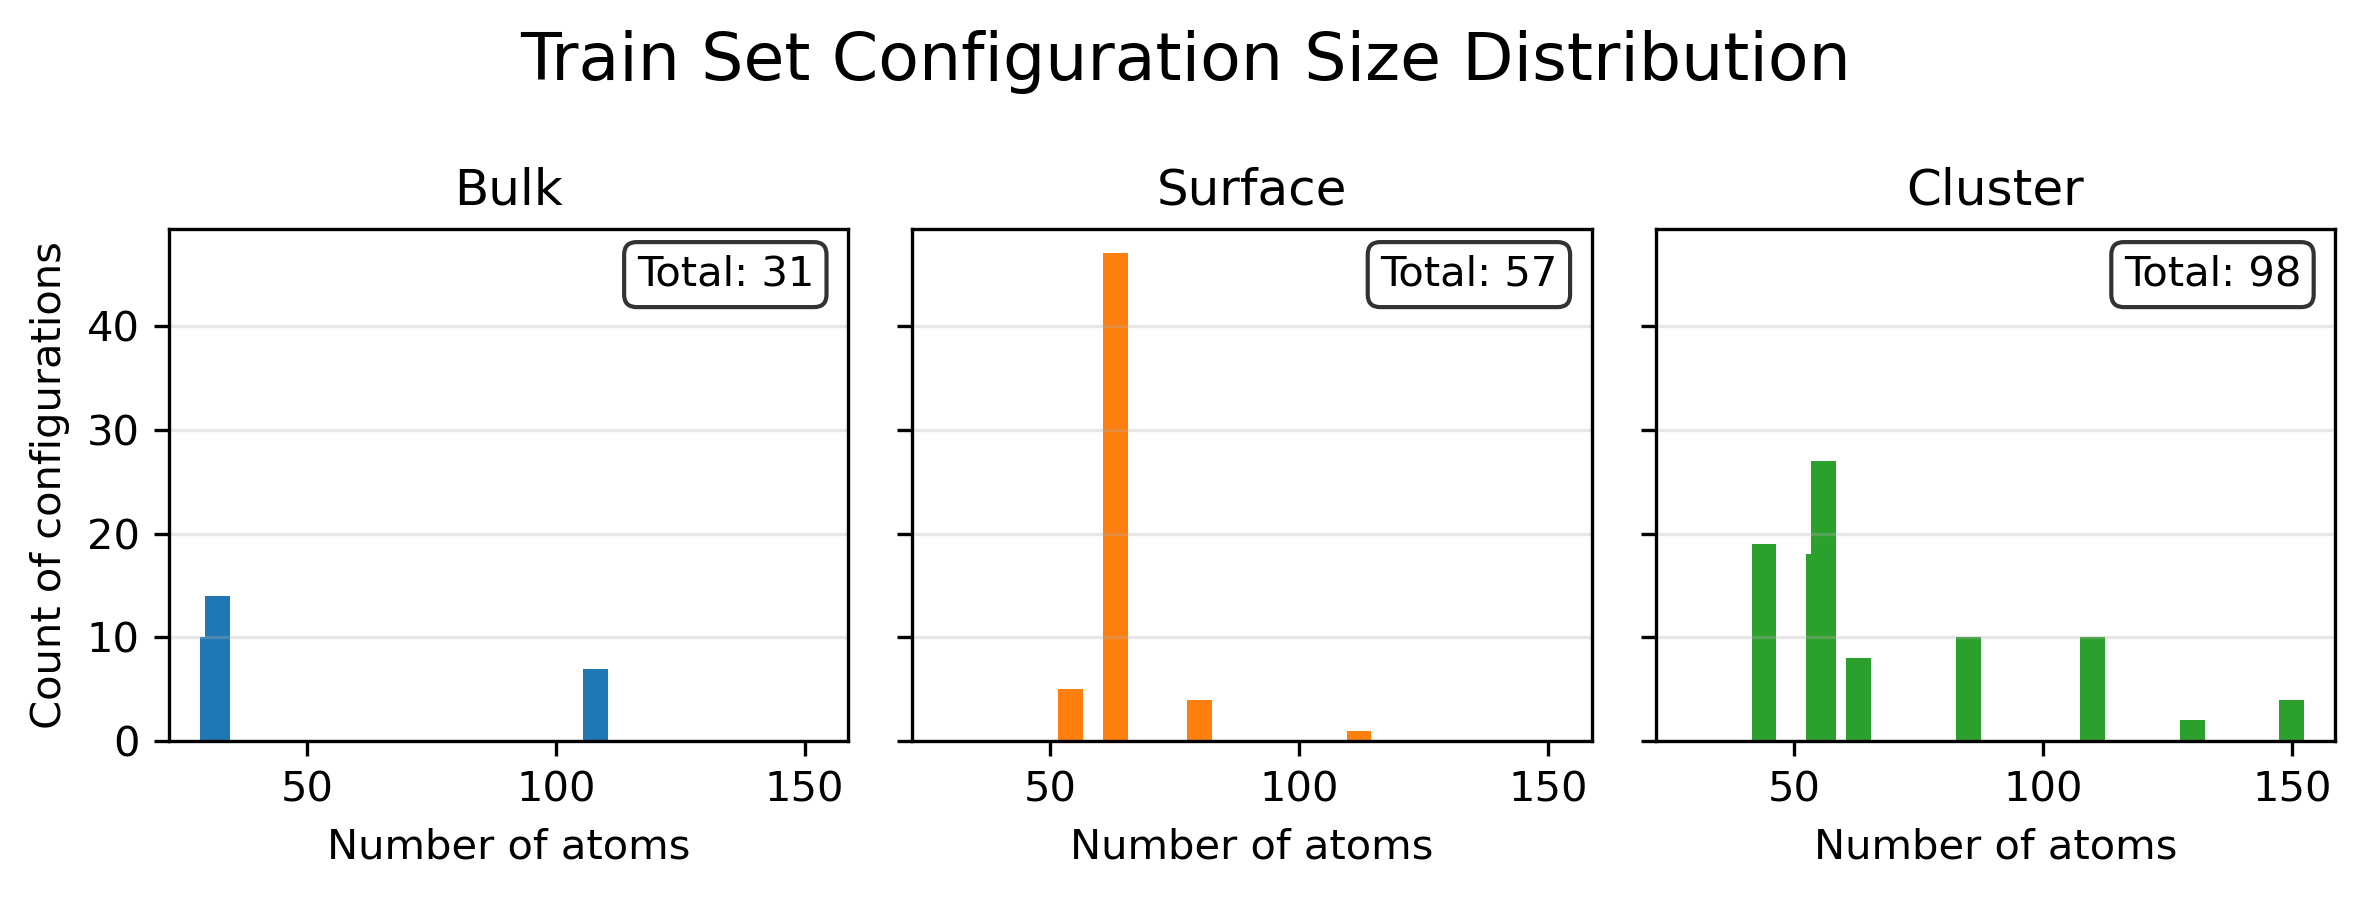

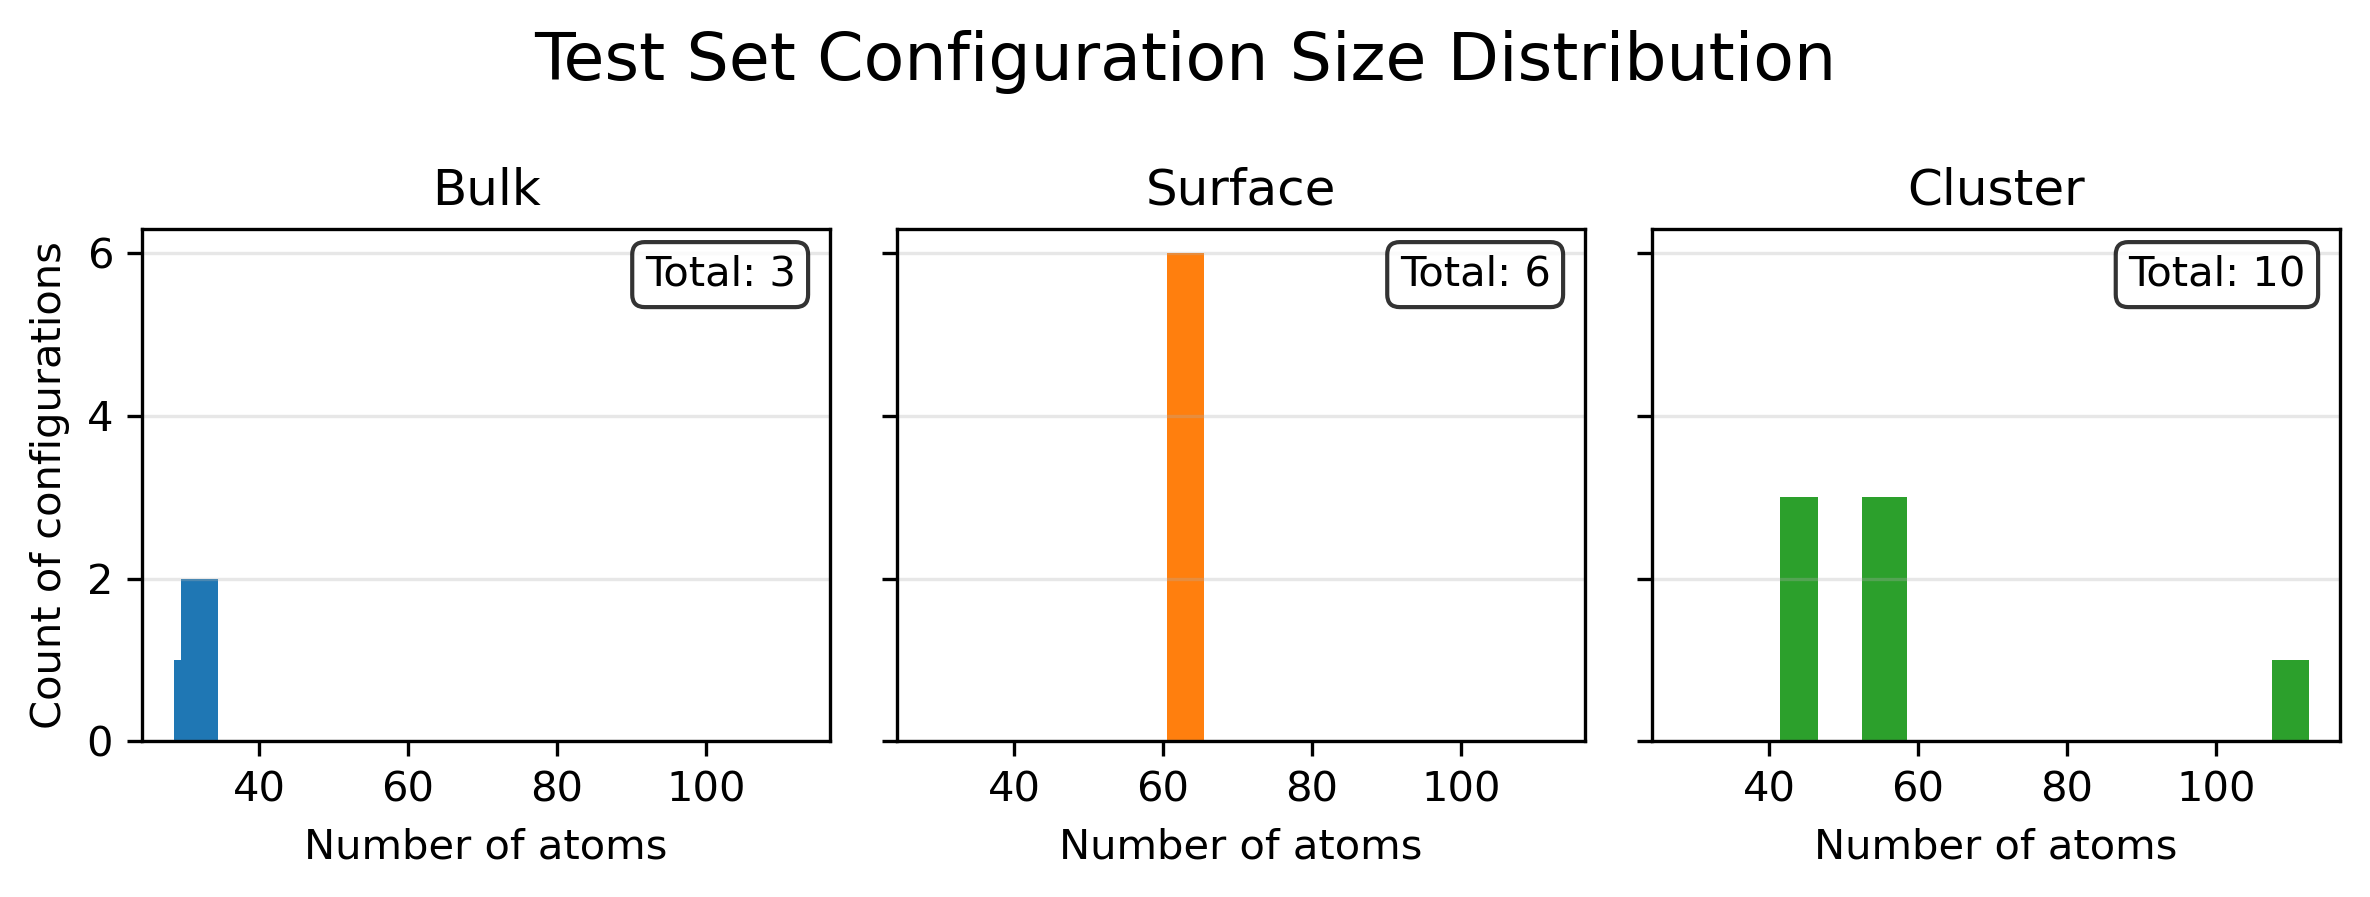

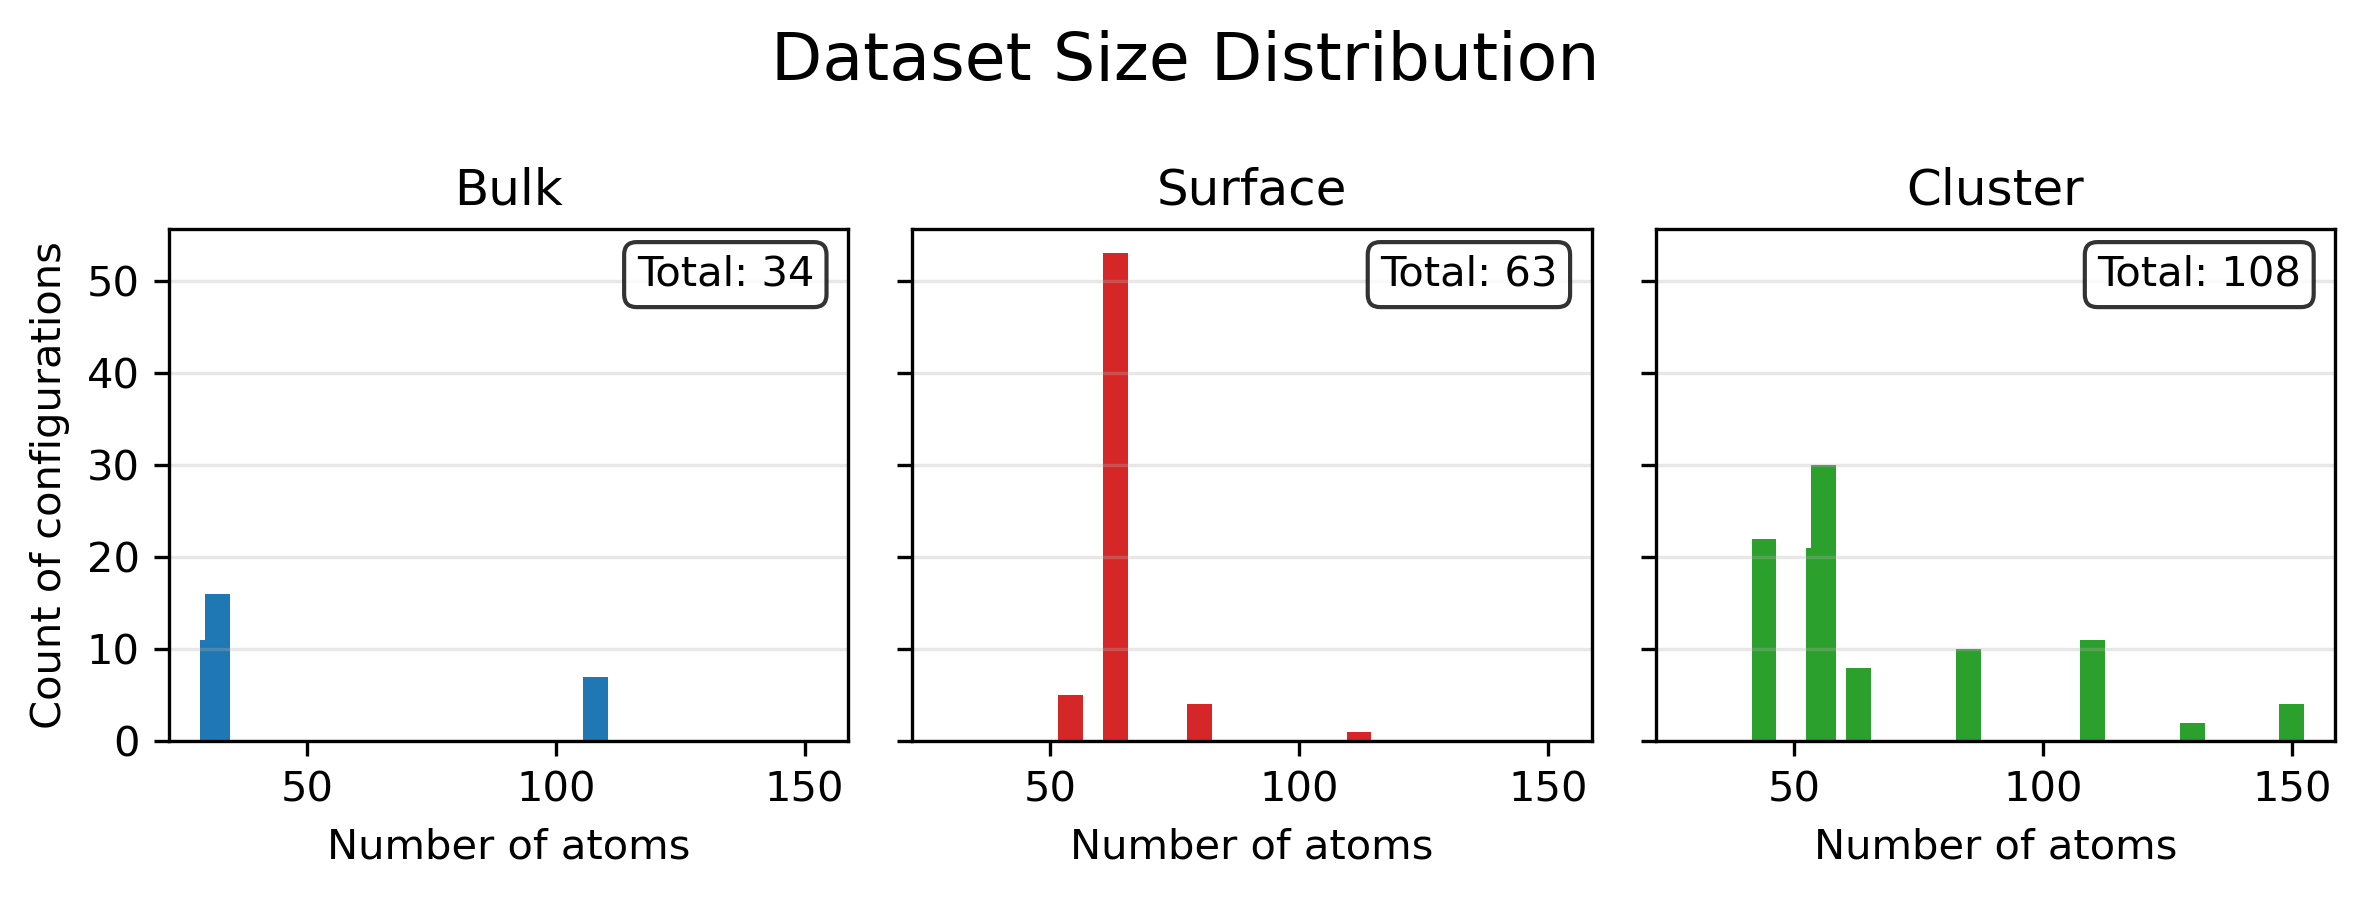

In [5]:
#plot dataset info
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

from mlputils.makesets import split_bulk_surf_clust as split

output_folder = 'database_postprocessing/'
os.makedirs(folder + output_folder, exist_ok=True)

# bulk_train, surf_train, clust_train = split(train)
# bulk_test, surf_test, clust_test = split(test)

# Count configurations by number of atoms
btrc = Counter(len(atoms) for atoms in bulk_train)
strc = Counter(len(atoms) for atoms in surf_train)
ctrc = Counter(len(atoms) for atoms in clust_train)

btec = Counter(len(atoms) for atoms in bulk_test)
stec = Counter(len(atoms) for atoms in surf_test)
ctec = Counter(len(atoms) for atoms in clust_test)

balc = Counter(len(atoms) for atoms in bulk_train+bulk_test)
salc = Counter(len(atoms) for atoms in surf_train+surf_test)
calc = Counter(len(atoms) for atoms in clust_train+clust_test)

def plot_subplots(counters, labels, colors, title, savepath=None):

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True, sharex=True, dpi=300)

    for ax, counter, label, color in zip(axes, counters, labels, colors):

        sizes = sorted(counter.keys())
        counts = [counter[size] for size in sizes]

        ax.bar(sizes, counts, color=color, width=5.0)

        total_configs = sum(counts)

        ax.text(
            0.95, 0.95,
            f'Total: {total_configs}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        ax.set_title(label)
        ax.set_xlabel('Number of atoms')

        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Count of configurations')

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()

    # plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# TRAIN SET
plot_subplots(
    counters=[btrc, strc, ctrc],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    title='Train Set Configuration Size Distribution',
    savepath=folder + output_folder + 'train_subplots.png'
)

# TEST SET
plot_subplots(
    counters=[btec, stec, ctec],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    title='Test Set Configuration Size Distribution',
    savepath=folder + output_folder + 'test_subplots.png'
)

#ALL SET
plot_subplots(
    counters=[balc, salc, calc],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:red', 'tab:green'],
    title='' \
    'Dataset Size Distribution',
    savepath=folder + output_folder + 'test_subplots.png'
)

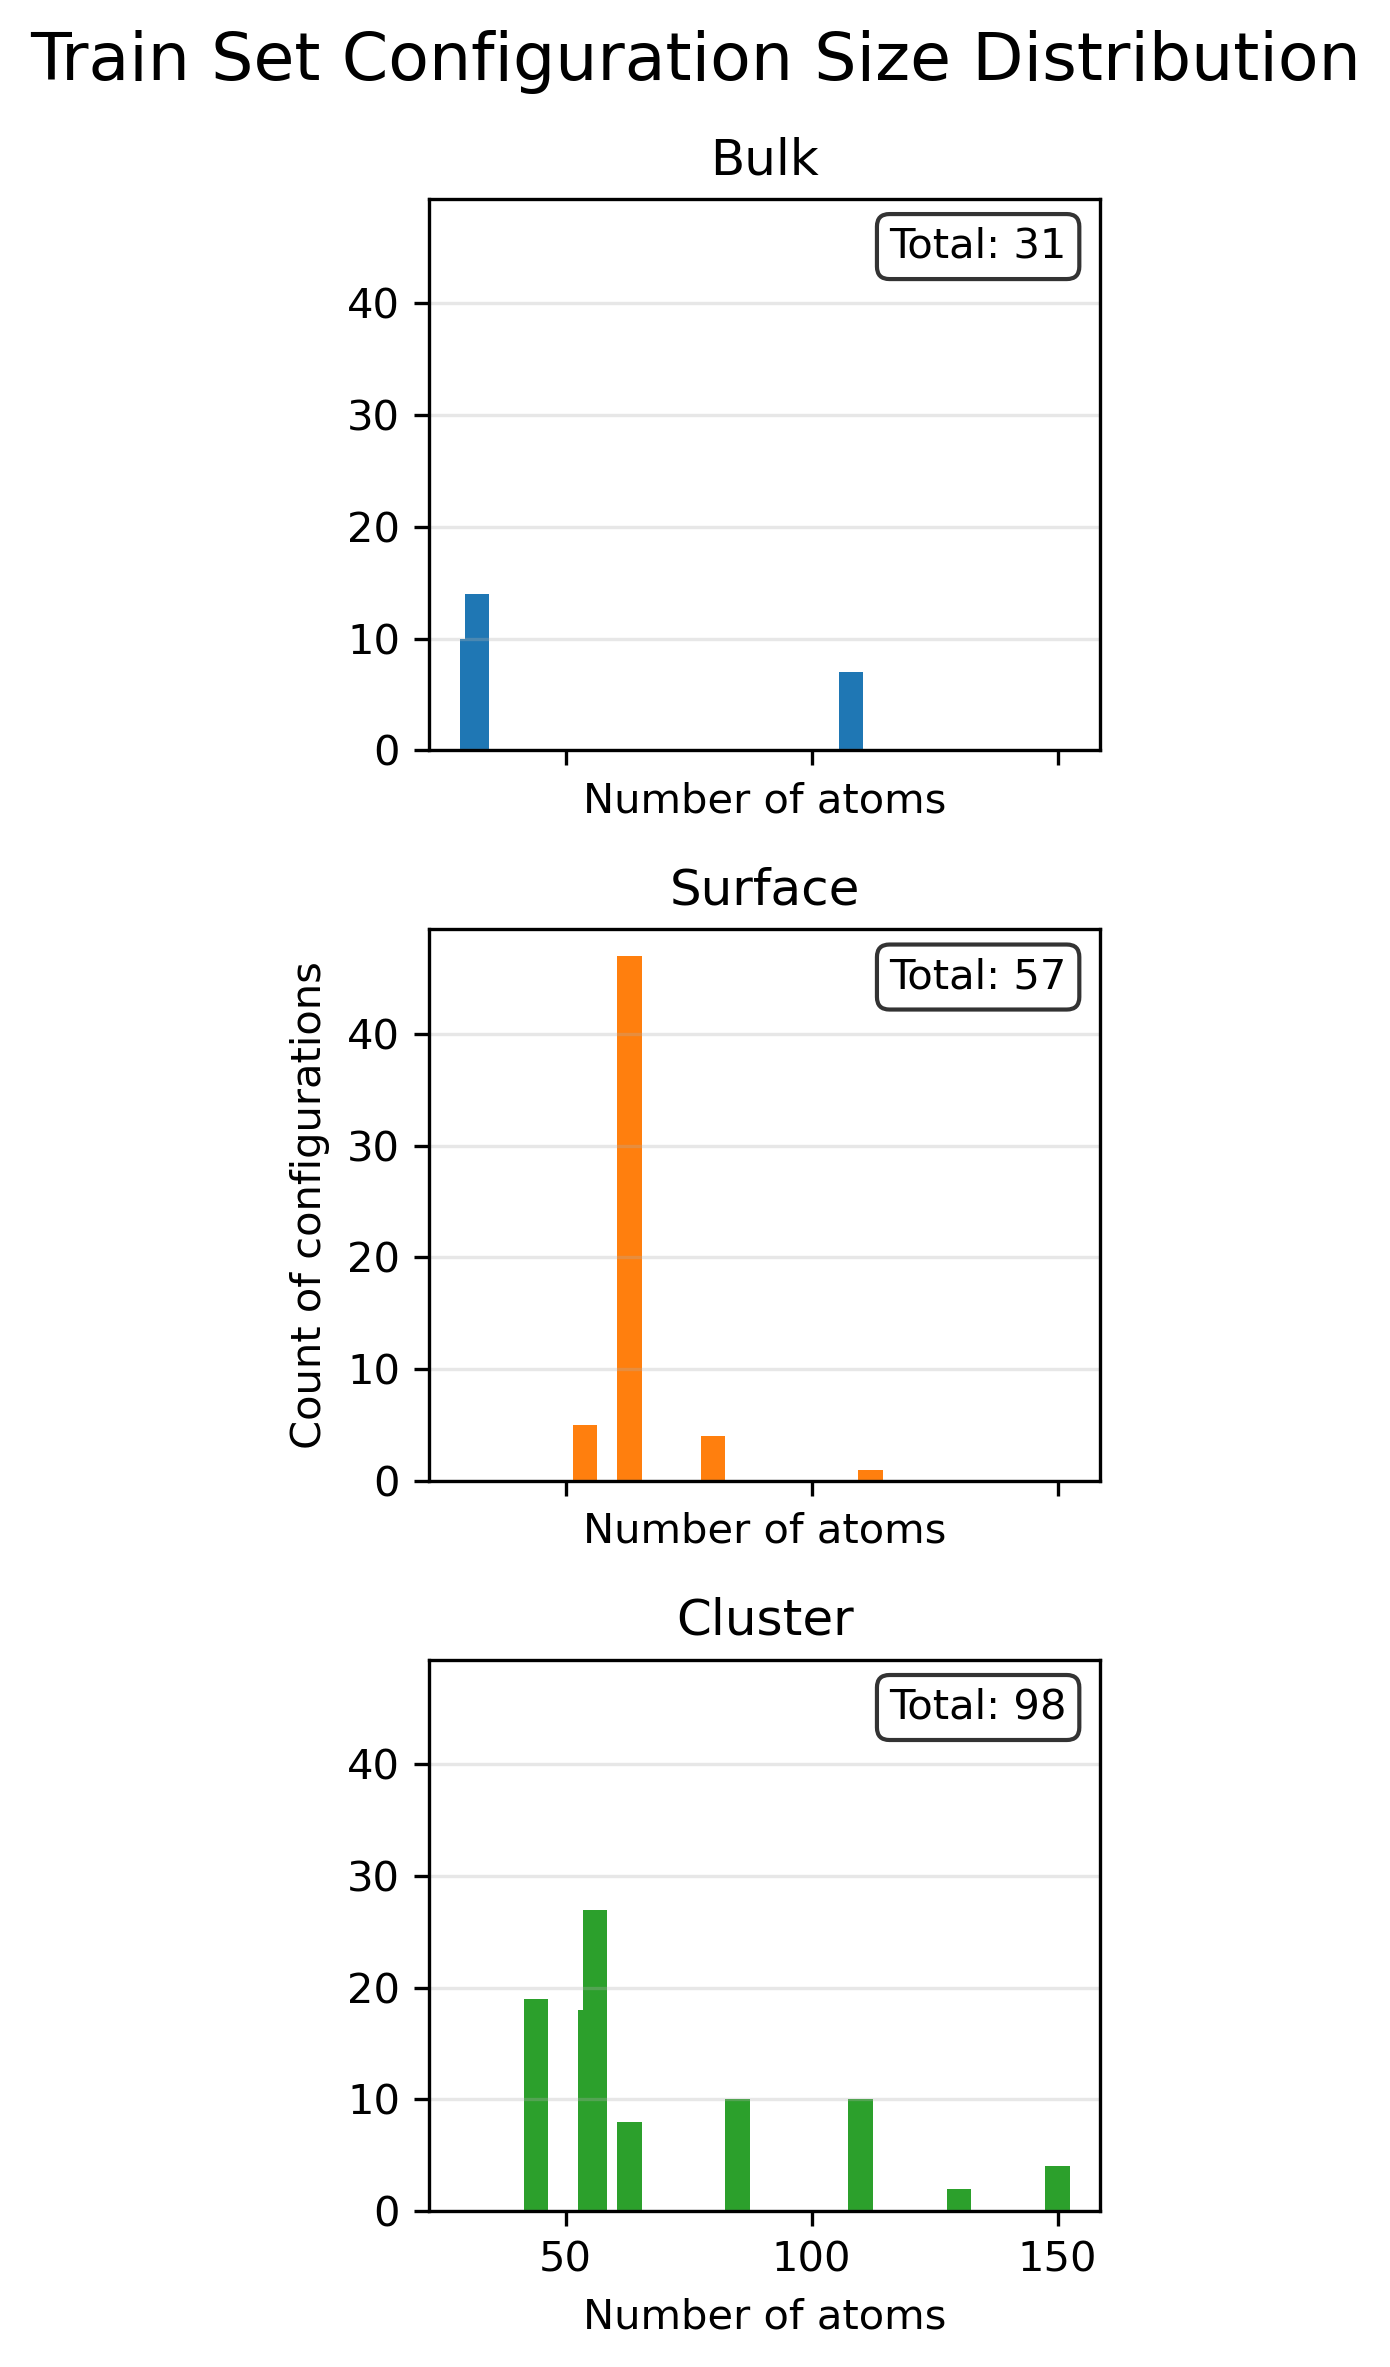

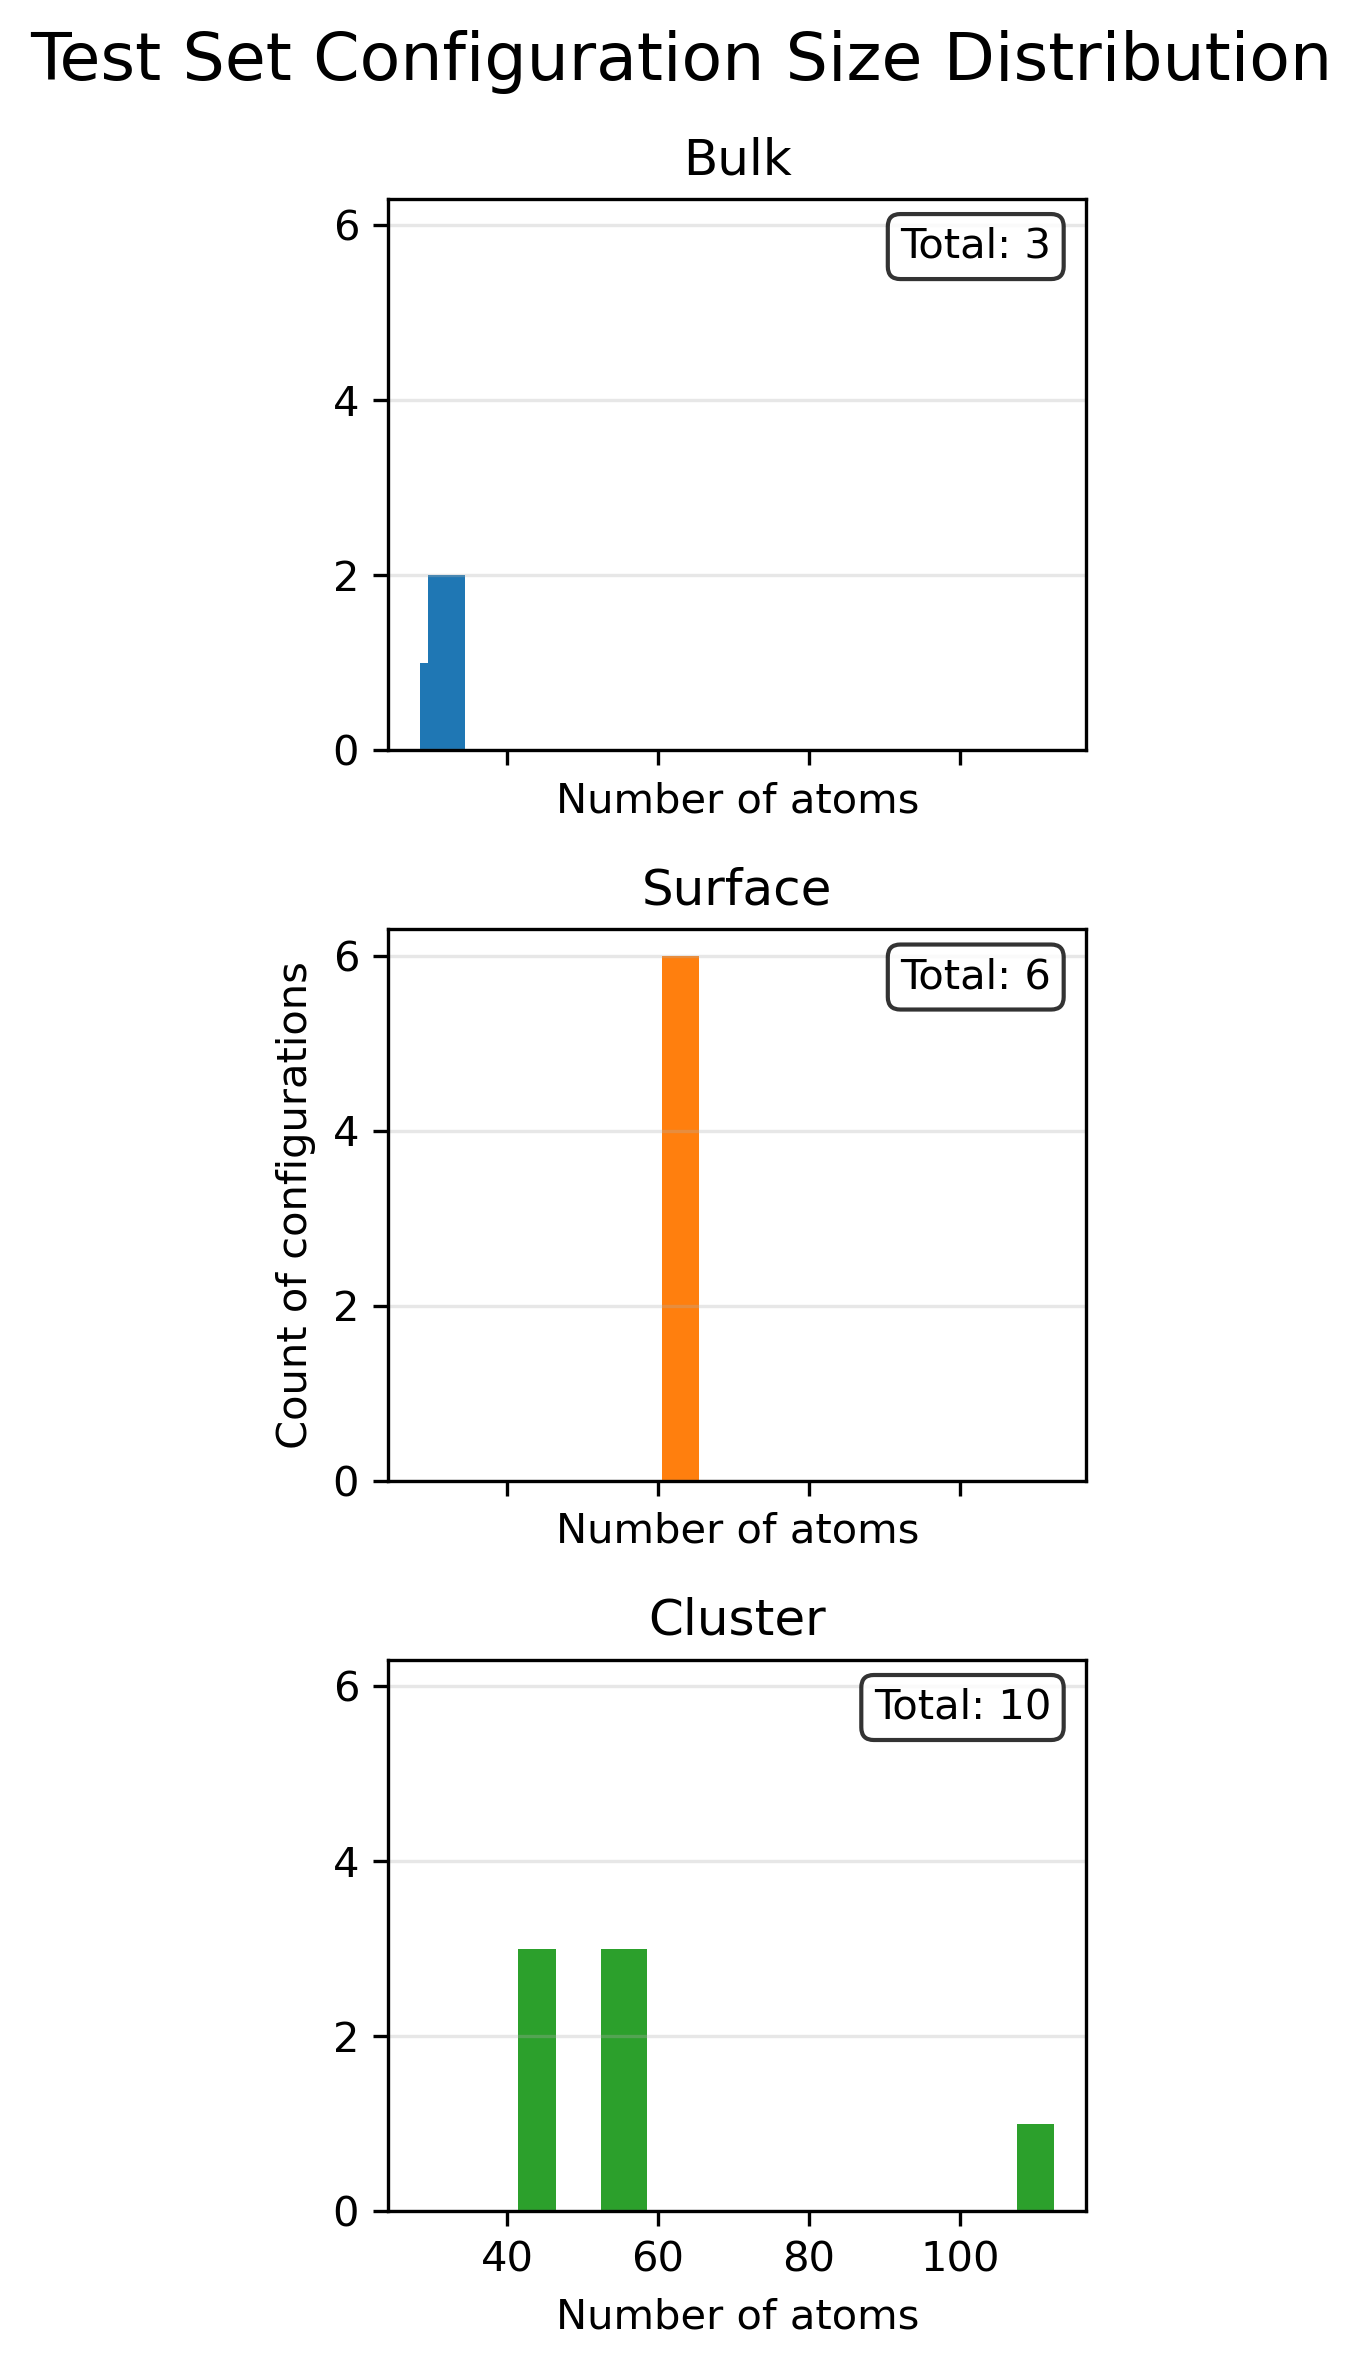

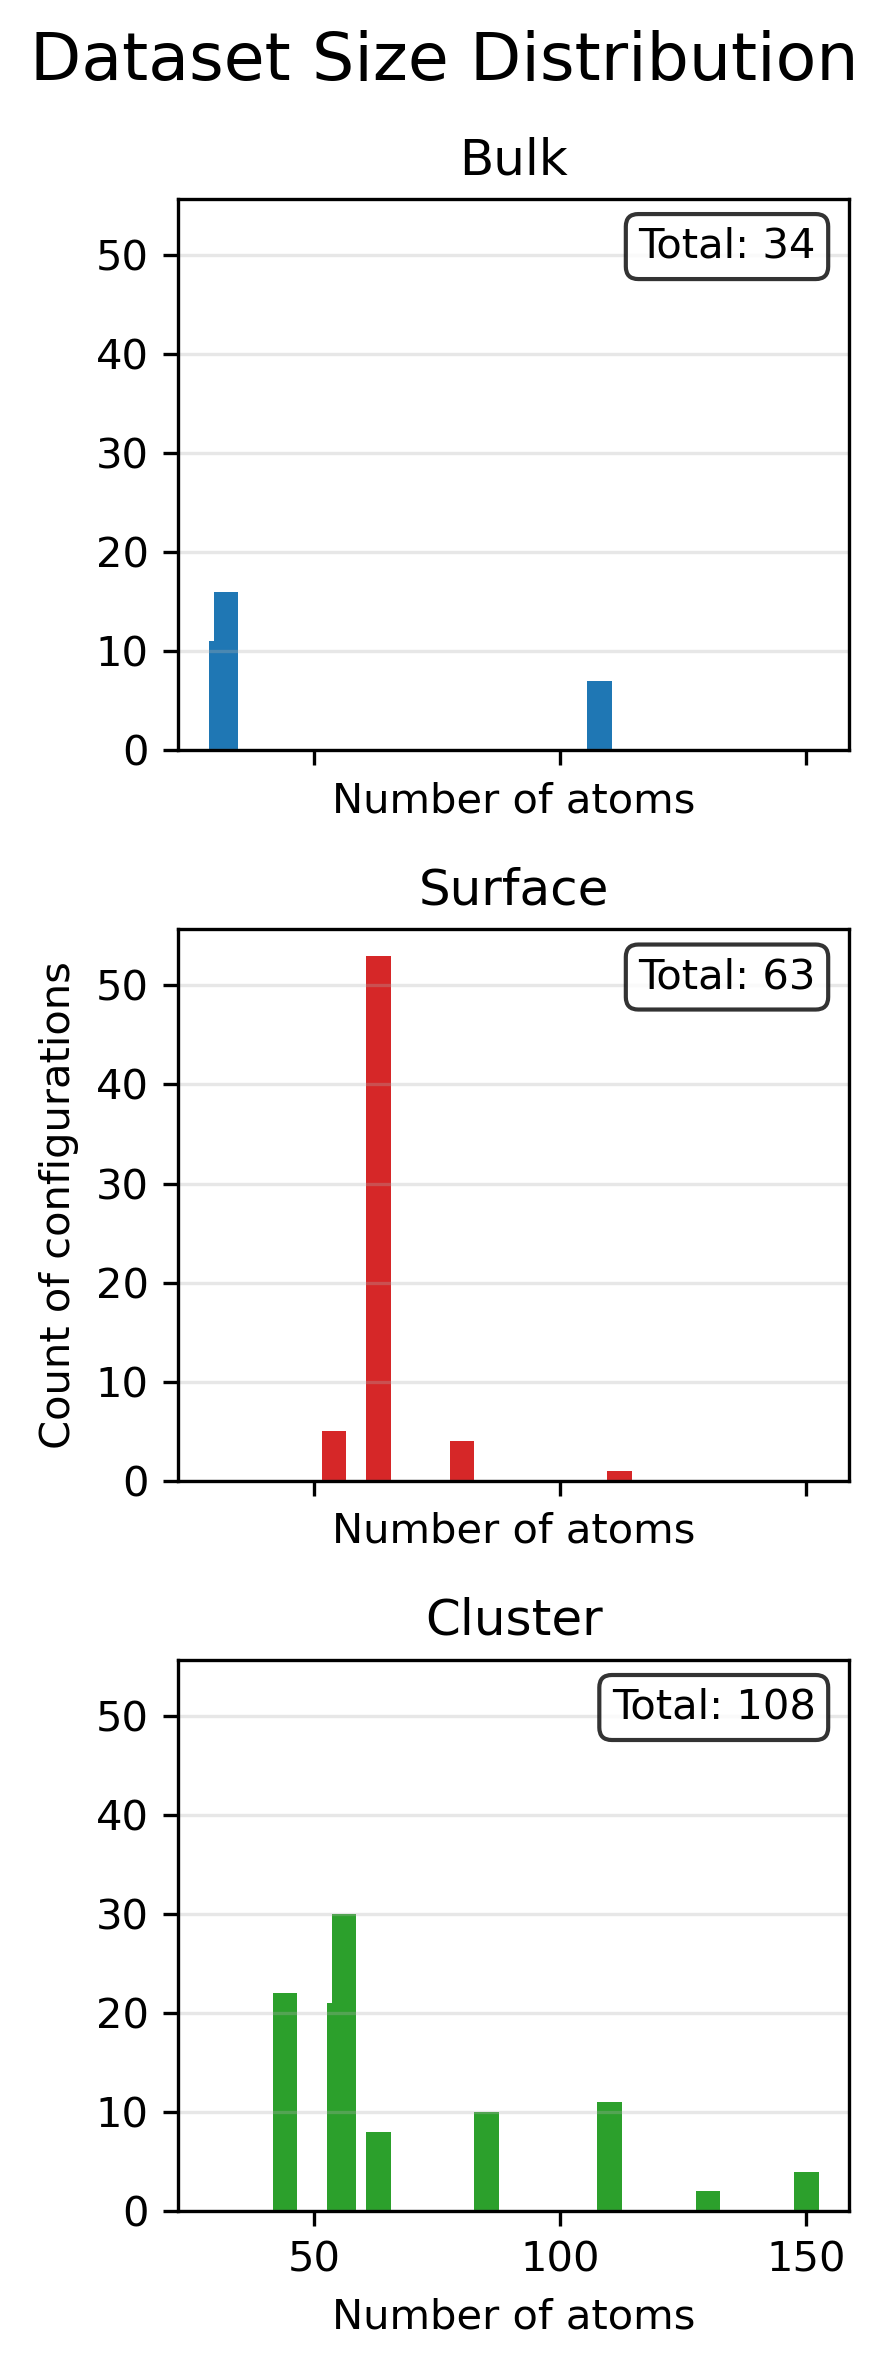

In [ ]:
#alternative vertical version - check if this is still right
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

output_folder = 'database_postprocessing/'
os.makedirs(folder + output_folder, exist_ok=True)

# bulk_train, surf_train, clust_train = split(train)
# bulk_test, surf_test, clust_test = split(test)

# Count configurations by number of atoms
btrc = Counter(len(atoms) for atoms in bulk_train)
strc = Counter(len(atoms) for atoms in surf_train)
ctrc = Counter(len(atoms) for atoms in clust_train)

btec = Counter(len(atoms) for atoms in bulk_test)
stec = Counter(len(atoms) for atoms in surf_test)
ctec = Counter(len(atoms) for atoms in clust_test)

balc = Counter(len(atoms) for atoms in bulk_train+bulk_test)
salc = Counter(len(atoms) for atoms in surf_train+surf_test)
calc = Counter(len(atoms) for atoms in clust_train+clust_test)


def plot_subplots(counters, labels, colors, title, savepath=None):

    fig, axes = plt.subplots(3, 1, figsize=(4, 8), sharey=True, sharex=True)

    for ax, counter, label, color in zip(axes, counters, labels, colors):

        sizes = sorted(counter.keys())
        counts = [counter[size] for size in sizes]

        ax.bar(sizes, counts, color=color, width=5.0)

        ax.set_title(label)
        ax.set_xlabel('Number of atoms')

        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Count of configurations')

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    #plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_subplots(counters, labels, colors, title, savepath=None):

    fig, axes = plt.subplots(3, 1, figsize=(3, 8), sharey=True, sharex=True, dpi=300)

    for ax, counter, label, color in zip(axes, counters, labels, colors):

        sizes = sorted(counter.keys())
        counts = [counter[size] for size in sizes]

        ax.bar(sizes, counts, color=color, width=5.0)

        total_configs = sum(counts)

        ax.text(
            0.95, 0.95,
            f'Total: {total_configs}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )

        ax.set_title(label)
        ax.set_xlabel('Number of atoms')

        ax.grid(axis='y', alpha=0.3)

    axes[1].set_ylabel('Count of configurations')

    fig.suptitle(title, fontsize=16)

    plt.tight_layout()

    # plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# TRAIN SET
plot_subplots(
    counters=[btrc, strc, ctrc],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    title='Train Set Configuration Size Distribution',
    savepath=folder + output_folder + 'train_subplots.png'
)

# TEST SET
plot_subplots(
    counters=[btec, stec, ctec],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    title='Test Set Configuration Size Distribution',
    savepath=folder + output_folder + 'test_subplots.png'
)

#ALL SET
plot_subplots(
    counters=[balc, salc, calc],
    labels=['Bulk', 'Surface', 'Cluster'],
    colors=['tab:blue', 'tab:red', 'tab:green'],
    title='' \
    'Dataset Size Distribution',
    savepath=folder + output_folder + 'test_subplots.png'
)

## Validation

It would be nice to color-code points on parity plots depending on whether these are bulk/surf/clusters configurations. This would require some work in the error computer function.

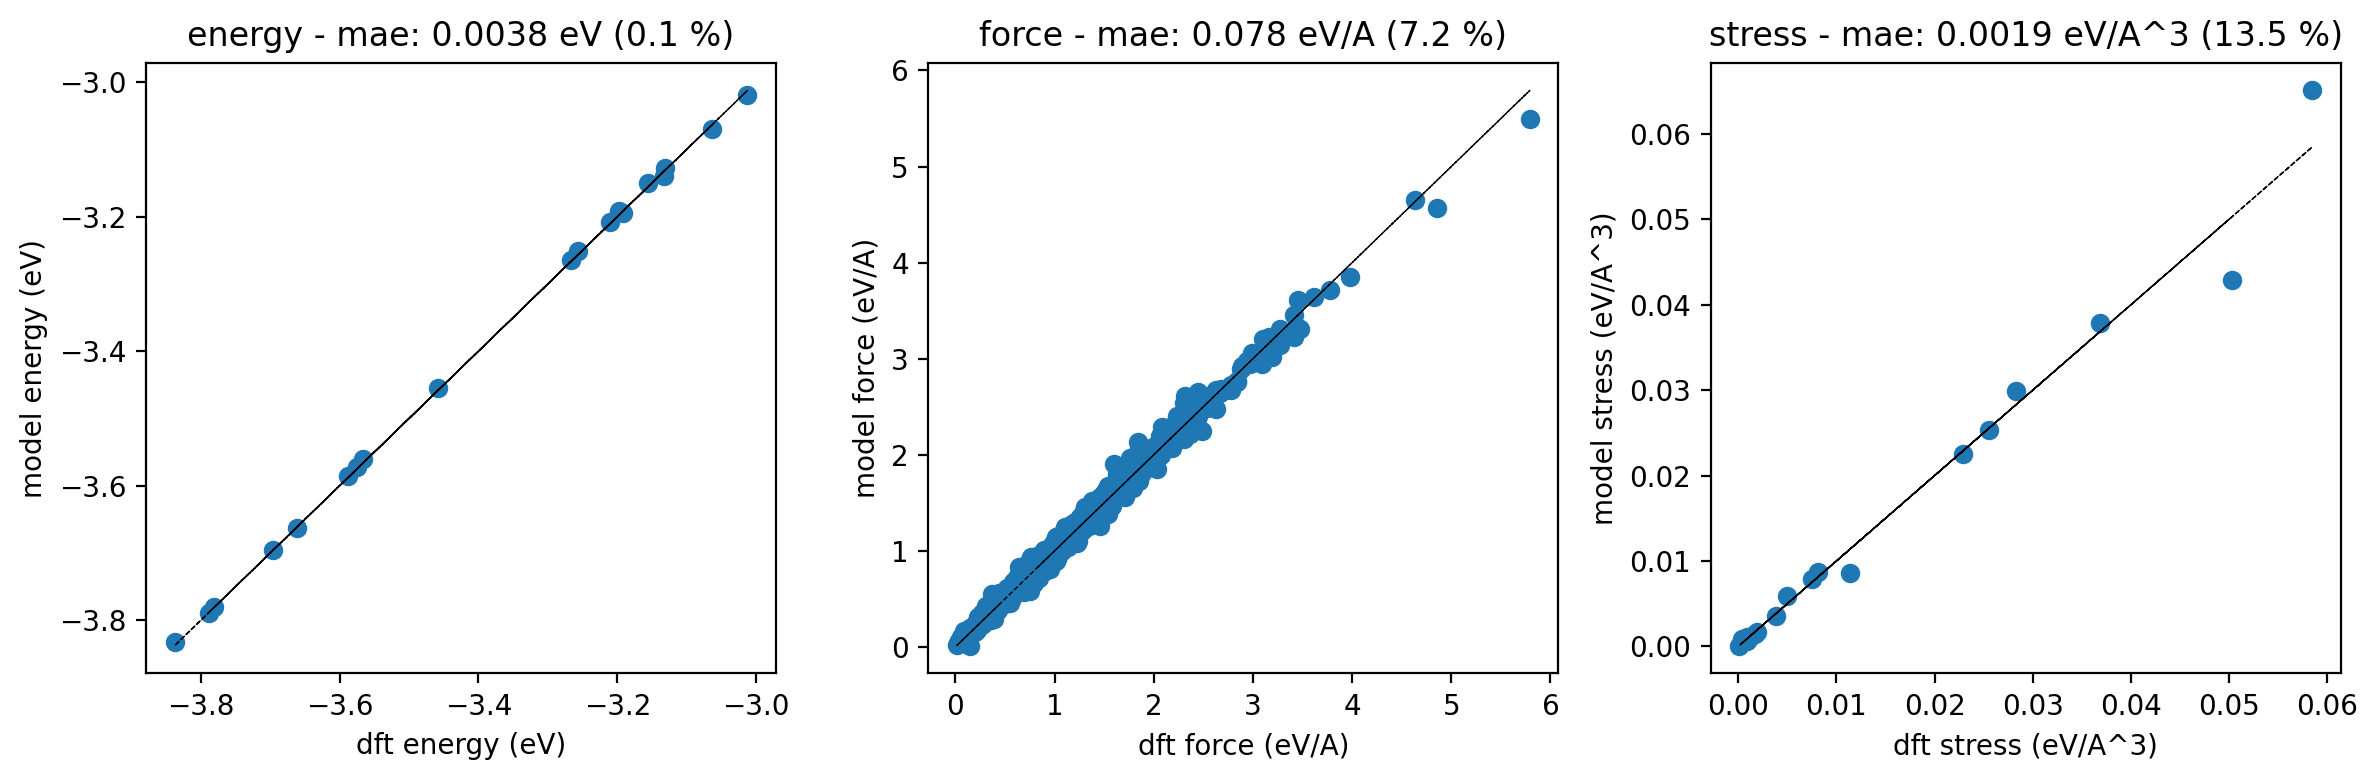

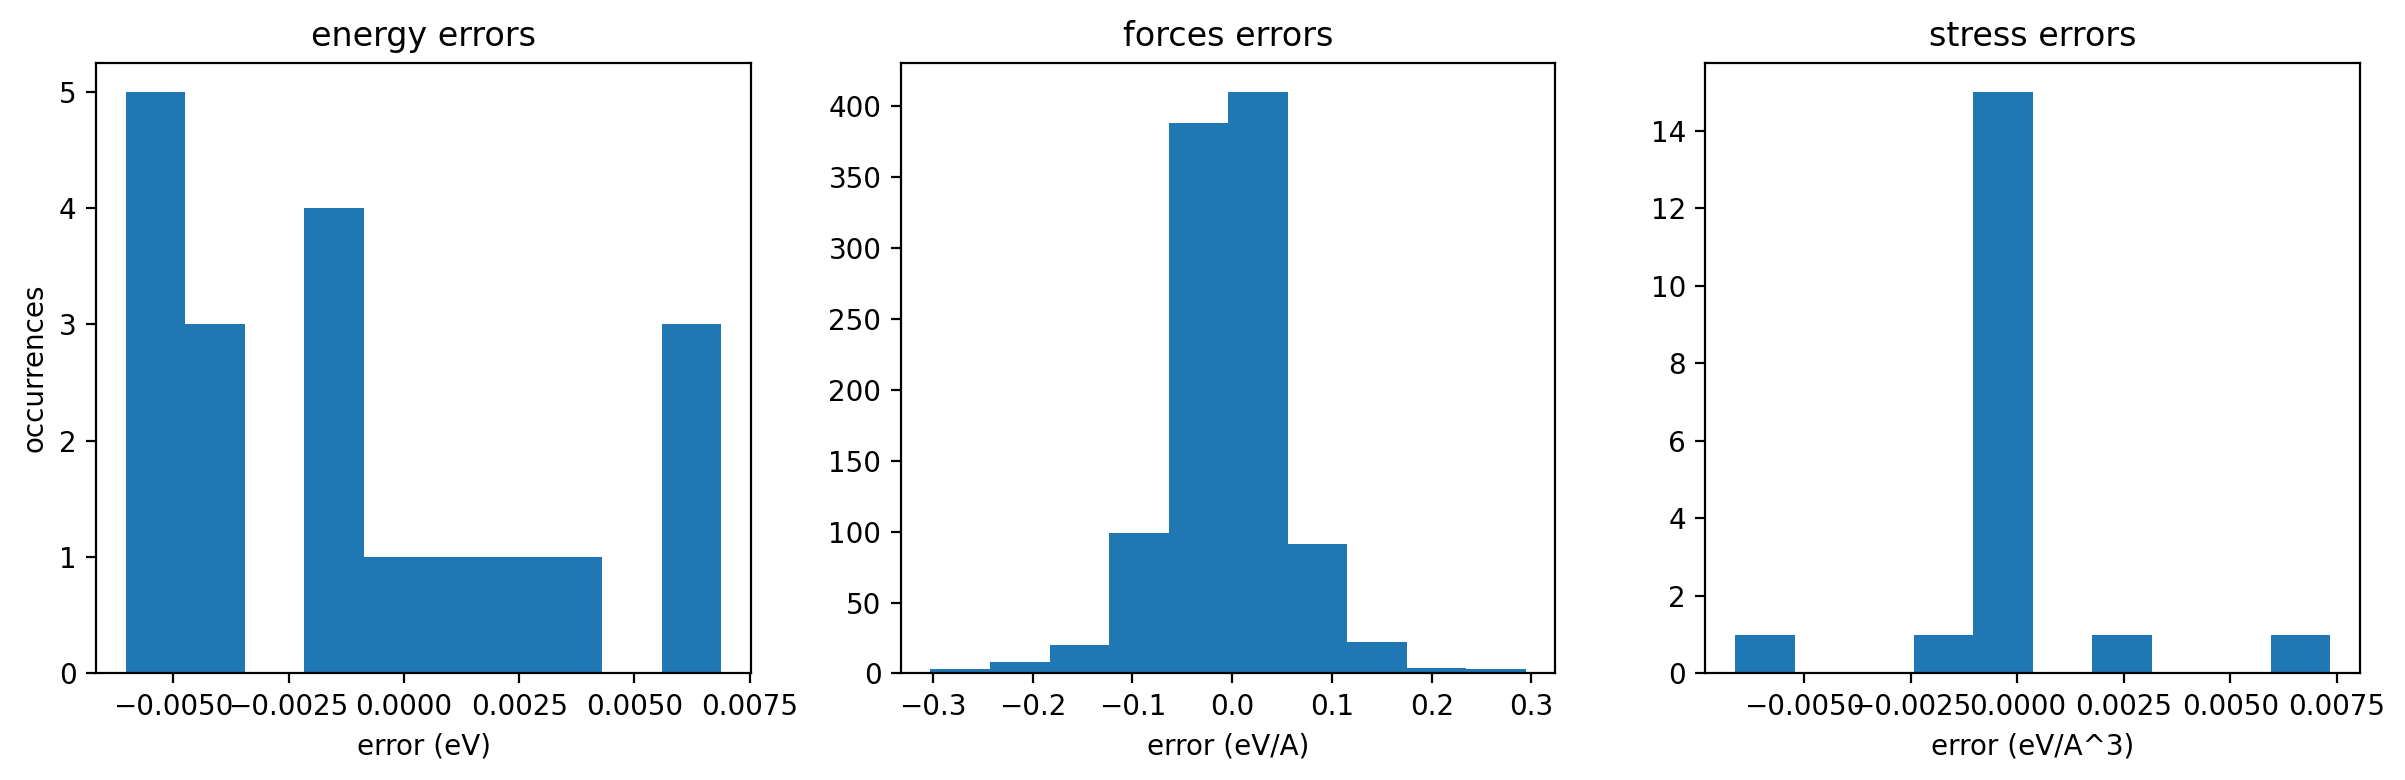

In [6]:
#errors and parity plots
fig, axs = plt.subplots(1,3,dpi=200, figsize=(12,4))

#energy errors
e_dft, e_model = np.loadtxt(folder+'_test.xyz_e-parity.dat', unpack=True)
axs[0].scatter(e_dft, e_model)
axs[0].set_xlabel('dft energy (eV)')
axs[0].set_ylabel('model energy (eV)')
axs[0].plot(e_dft, e_dft, linestyle='--', linewidth=0.5, color='k')
axs[0].set_title(f"energy - {err_style}: {benchmarks.get(testset_file).get('energy_per_atom').get(err_style):.4f} eV ({benchmarks.get(testset_file).get('energy_per_atom').get('ratio_x100'):.1f} %)")

#forces errors
f_dft, f_model = np.loadtxt(folder+'_test.xyz_f-parity.dat', unpack=True)
axs[1].scatter(f_dft, f_model)
axs[1].set_xlabel('dft force (eV/A)')
axs[1].set_ylabel('model force (eV/A)')
axs[1].plot(f_dft, f_dft, linestyle='--', linewidth=0.5, color='k')
axs[1].set_title(f"force - {err_style}: {benchmarks.get(testset_file).get('forces').get(err_style):.3f} eV/A ({benchmarks.get(testset_file).get('forces').get('ratio_x100'):.1f} %)")

#stress errors
s_dft, s_model = np.loadtxt(folder+'_test.xyz_s-parity.dat', unpack=True)
axs[2].scatter(s_dft, s_model)
axs[2].set_xlabel('dft stress (eV/A^3)')
axs[2].set_ylabel('model stress (eV/A^3)')
axs[2].plot(s_dft, s_dft, linestyle='--', linewidth=0.5, color='k')
axs[2].set_title(f"stress - {err_style}: {benchmarks.get(testset_file).get('stress').get(err_style):.4f} eV/A^3 ({benchmarks.get(testset_file).get('stress').get('ratio_x100'):.1f} %)")

plt.tight_layout()

#histogram of the spread of the errors
fig, axs = plt.subplots(1,3,dpi=200, figsize=(12,4))
axs[0].hist(e_dft-e_model)
axs[0].set_xlabel('error (eV)')
axs[0].set_ylabel('occurrences')
axs[0].set_title('energy errors')

axs[1].hist(f_dft-f_model)
axs[1].set_xlabel('error (eV/A)')
axs[1].set_title('forces errors')

axs[2].hist(s_dft-s_model)
axs[2].set_xlabel('error (eV/A^3)')
axs[2].set_title('stress errors')

plt.tight_layout()


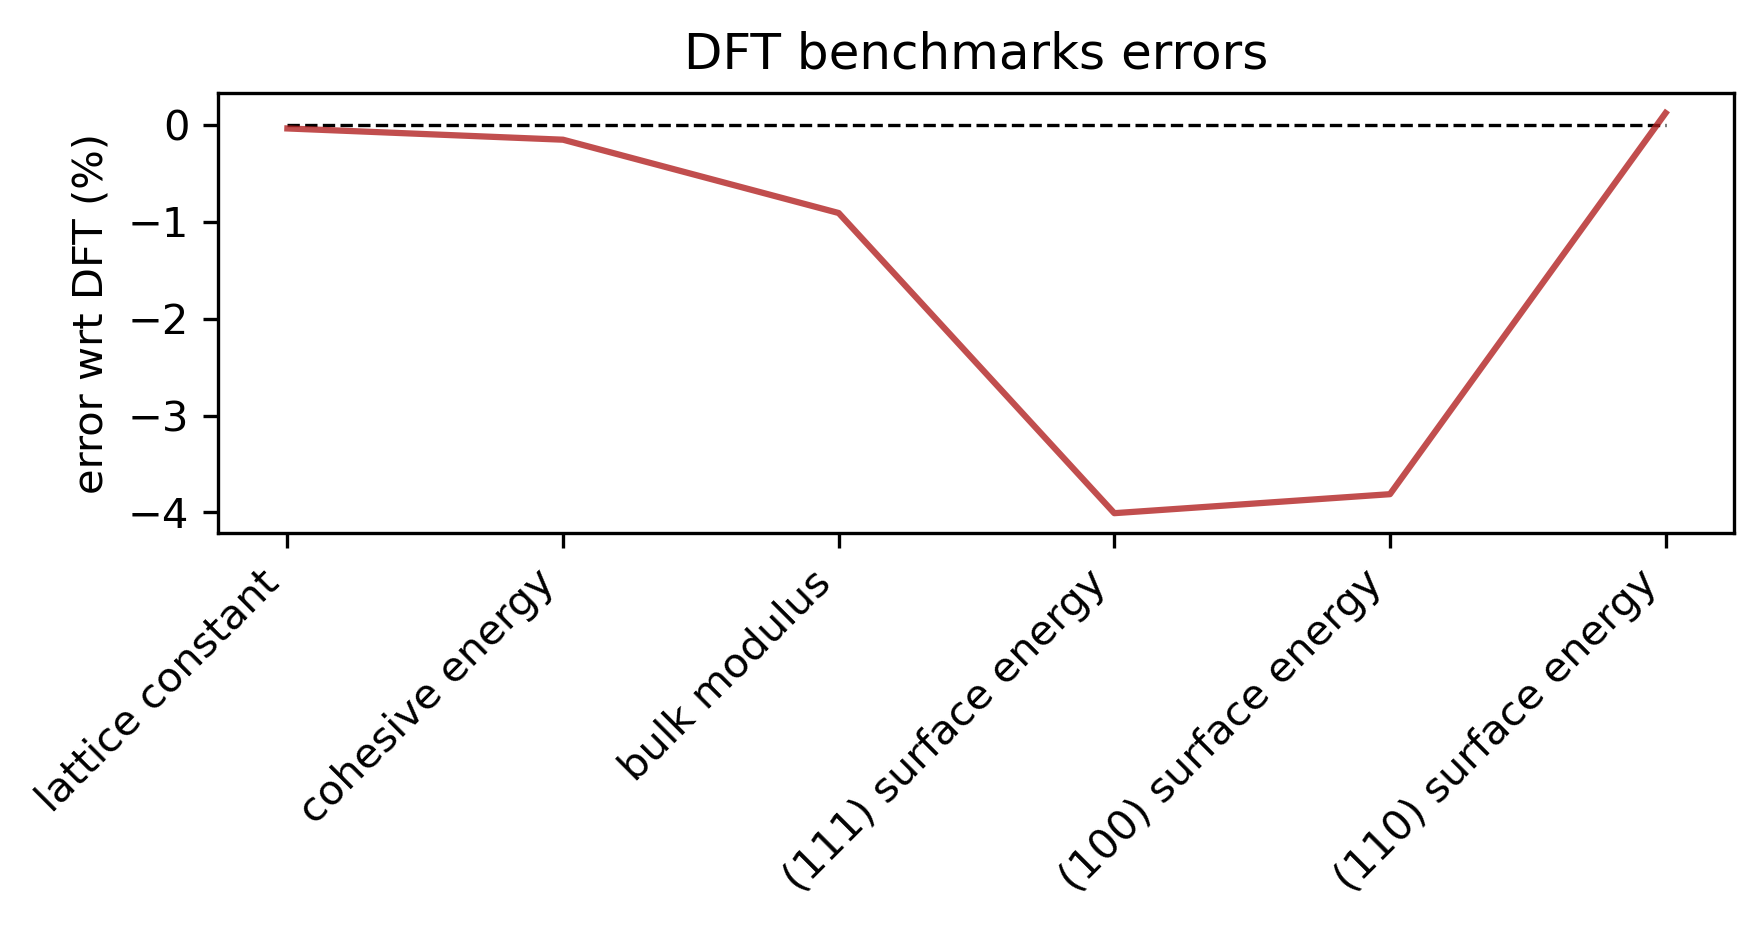

In [7]:
#dft references

labels = ["lattice constant", "cohesive energy", "bulk modulus", 
              "(111) surface energy", "(100) surface energy","(110) surface energy"]
x = np.arange(len(labels))

plt.figure(dpi=300, figsize=(6,3.2))
plt.title(f'DFT benchmarks errors')
plt.hlines(0,  min(x), max(x), linestyles='--', color='k', lw=0.8)


y = np.array([ benchmarks['fcc_bulk']['a0_rel_error'],
              benchmarks['fcc_bulk']['e0_rel_error'],
              benchmarks['fcc_bulk']['B_rel_error'],
              benchmarks['fcc111']['rel_error'],
              benchmarks['fcc100']['rel_error'],
              benchmarks['fcc110']['rel_error']])
            
plt.plot(x,  y, alpha=0.8, color='firebrick')
    
plt.xlabel("")
plt.xticks(x, labels, rotation=45., ha='right')
plt.ylabel("error wrt DFT (%)")
plt.tight_layout()

could not open file: /Users/ginardi/Desktop/science/55Ry/Cu/cnap/cnap_2.984/update_hole/ico-exc.dat not found.
could not open file: /Users/ginardi/Desktop/science/55Ry/Cu/cnap/cnap_2.984/update_hole/mdh-exc.dat not found.
could not open file: /Users/ginardi/Desktop/science/55Ry/Cu/cnap/cnap_2.984/update_hole/oh-exc.dat not found.
could not open file: /Users/ginardi/Desktop/science/55Ry/Cu/cnap/cnap_2.984/update_hole/rto-exc.dat not found.


Text(0.5, 1.0, 'Excess energy of families of clusters')

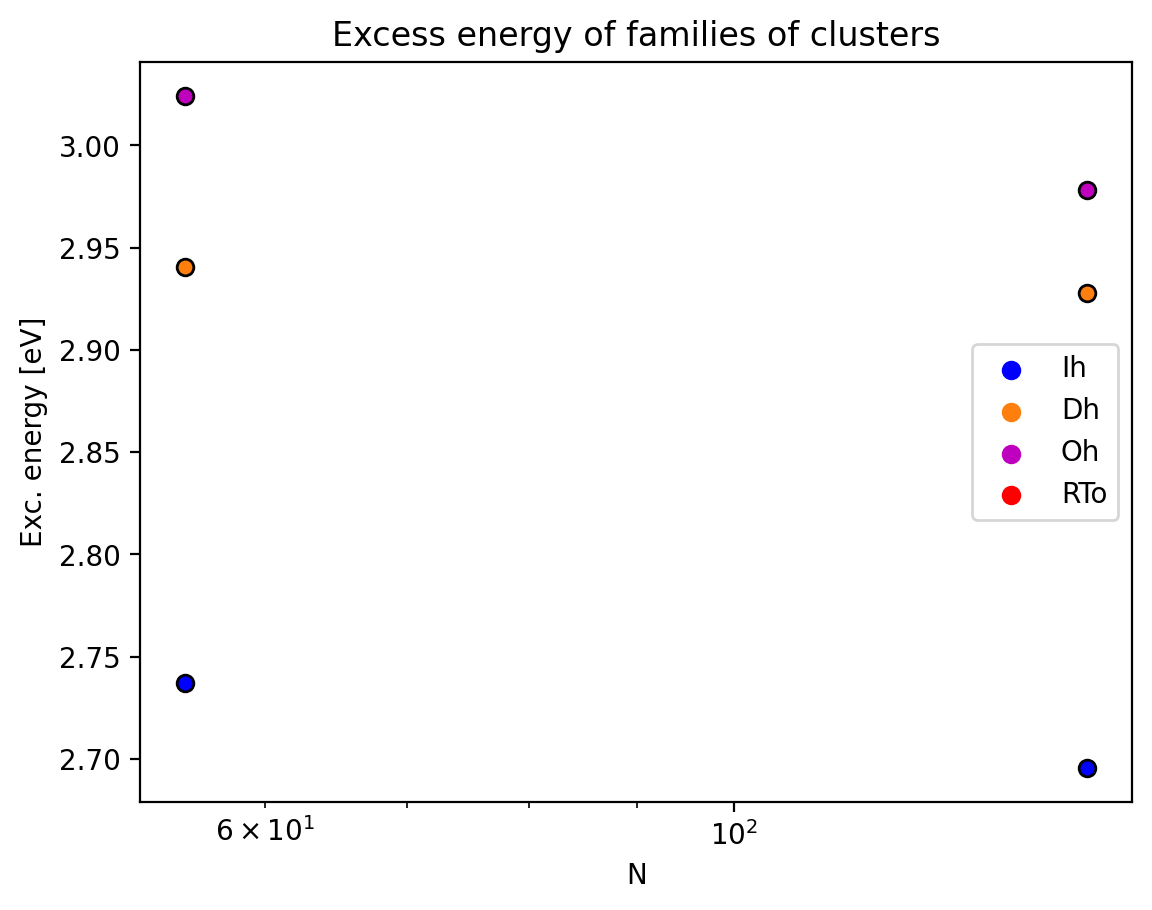

In [10]:
#excess energy - if you have that computed
#expecting data as per-NP-type files (e.g. ico-excess-energy.txt)
#as computed by clusters-excess-energies/ (another github repo of mine)
ico_file = 'ico-exc.dat'
mdh_file = 'mdh-exc.dat'
oh_file  = 'oh-exc.dat'
rto_file = 'rto-exc.dat'

names = ['Ih', 'Dh', 'Oh', 'RTo']
colors = ['b', 'tab:orange', 'm', 'r']
references = [ [[55, 147], [benchmarks.get('special_configs').get(f'{element}_Ih_55_relax.pwo').get('ref_excess_energy'), benchmarks.get('special_configs').get(f'{element}_Ih_147_relax.pwo').get('ref_excess_energy')]],
                [[55, 147], [benchmarks.get('special_configs').get(f'{element}_Dh_55_relax.pwo').get('ref_excess_energy'), benchmarks.get('special_configs').get(f'{element}_Dh_147_relax.pwo').get('ref_excess_energy')]],
                [[55, 147], [benchmarks.get('special_configs').get(f'{element}_Oh_55_relax.pwo').get('ref_excess_energy'), benchmarks.get('special_configs').get(f'{element}_Oh_147_relax.pwo').get('ref_excess_energy')]],
                [[],[]] ]

#load data
try:
    ico_N, _, ico_e = np.loadtxt(folder+ico_file, unpack=True)
except Exception as e:
    print('could not open file:',e)
    ico_N, ico_e = [], []
try:
    deca_N, _, deca_e = np.loadtxt(folder+mdh_file, unpack=True)
except Exception as e:
    print('could not open file:',e)
    deca_N, deca_e = [], []
try:
    oh_N, _, oh_e = np.loadtxt(folder+oh_file, unpack=True)
except Exception as e:
    print('could not open file:',e)
    oh_N, oh_e = [], []
try:
    rto_N, _, rto_e = np.loadtxt(folder+rto_file, unpack=True)
except Exception as e:
    print('could not open file:',e)
    rto_N, rto_e = [], []

model_ee = [ [ico_N, ico_e],
            [deca_N, deca_e],
            [oh_N, oh_e],
            [rto_N, rto_e] ]

#plot
plt.figure(dpi=200)

for name, color, ref, data in zip(names, colors, references, model_ee):
    plt.scatter(data[0], data[1], color=color, label=name)
    plt.scatter(ref[0], ref[1], color=color, edgecolors='k')

plt.xscale('log')
plt.xlabel('N')
plt.ylabel('Exc. energy [eV]')
plt.legend()
plt.title('Excess energy of families of clusters')

# Potential stability on critical regions

Some specific regions of the configruations space are often critically unrepresented in common databases. A couple of examples are analyzed here:
 - the dimer curve up to the potential's cutoff
 - the potential energy curves of atoms detached from the surface of a slab, or a nanoparticle. 
 - the bulk equation of state up to very large lattice parameters.

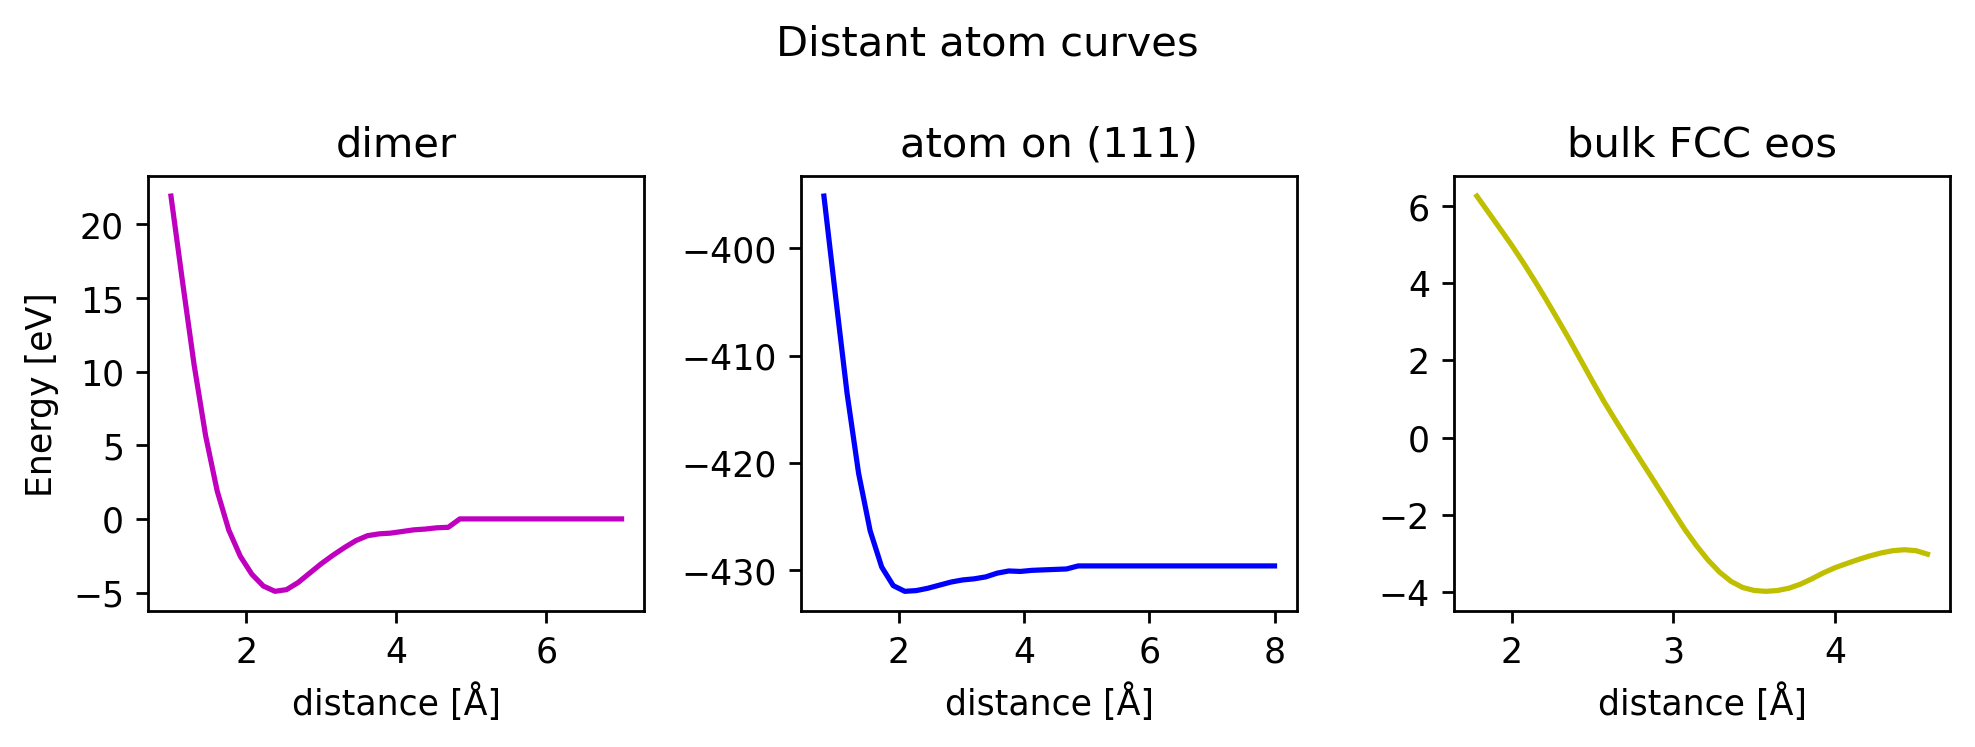

In [11]:
#critical stability regions plots
files  = [folder+'dimer_curve.dat', folder+'adsorbate_curve.dat', folder+'large_eos_curve.dat']
colors = ['m', 'b', 'y']
titles = ['dimer', 'atom on (111)', 'bulk FCC eos']
fig, axs = plt.subplots(1, len(files), figsize = (8,3), dpi=250)

for f, a, c, t in zip(files, axs, colors, titles):
    data = np.loadtxt(f)
    if f==folder+'large_eos_curve.dat':
        data[:,1] = data[:,1]/4 #4 atoms per conv. cell
    a.plot(data[:,0], data[:,1], color=c)
    a.set_xlabel('distance [Å]')
    a.set_title(t)

axs[0].set_ylabel('Energy [eV]')
plt.suptitle(f'Distant atom curves')
plt.tight_layout()

Prediction on some specific configuration can be relevant. Here we compare the prediction of energy on relaxed 55-atoms isomers, to check if the errors on these never-seen-before configurations is close to that on the test set.

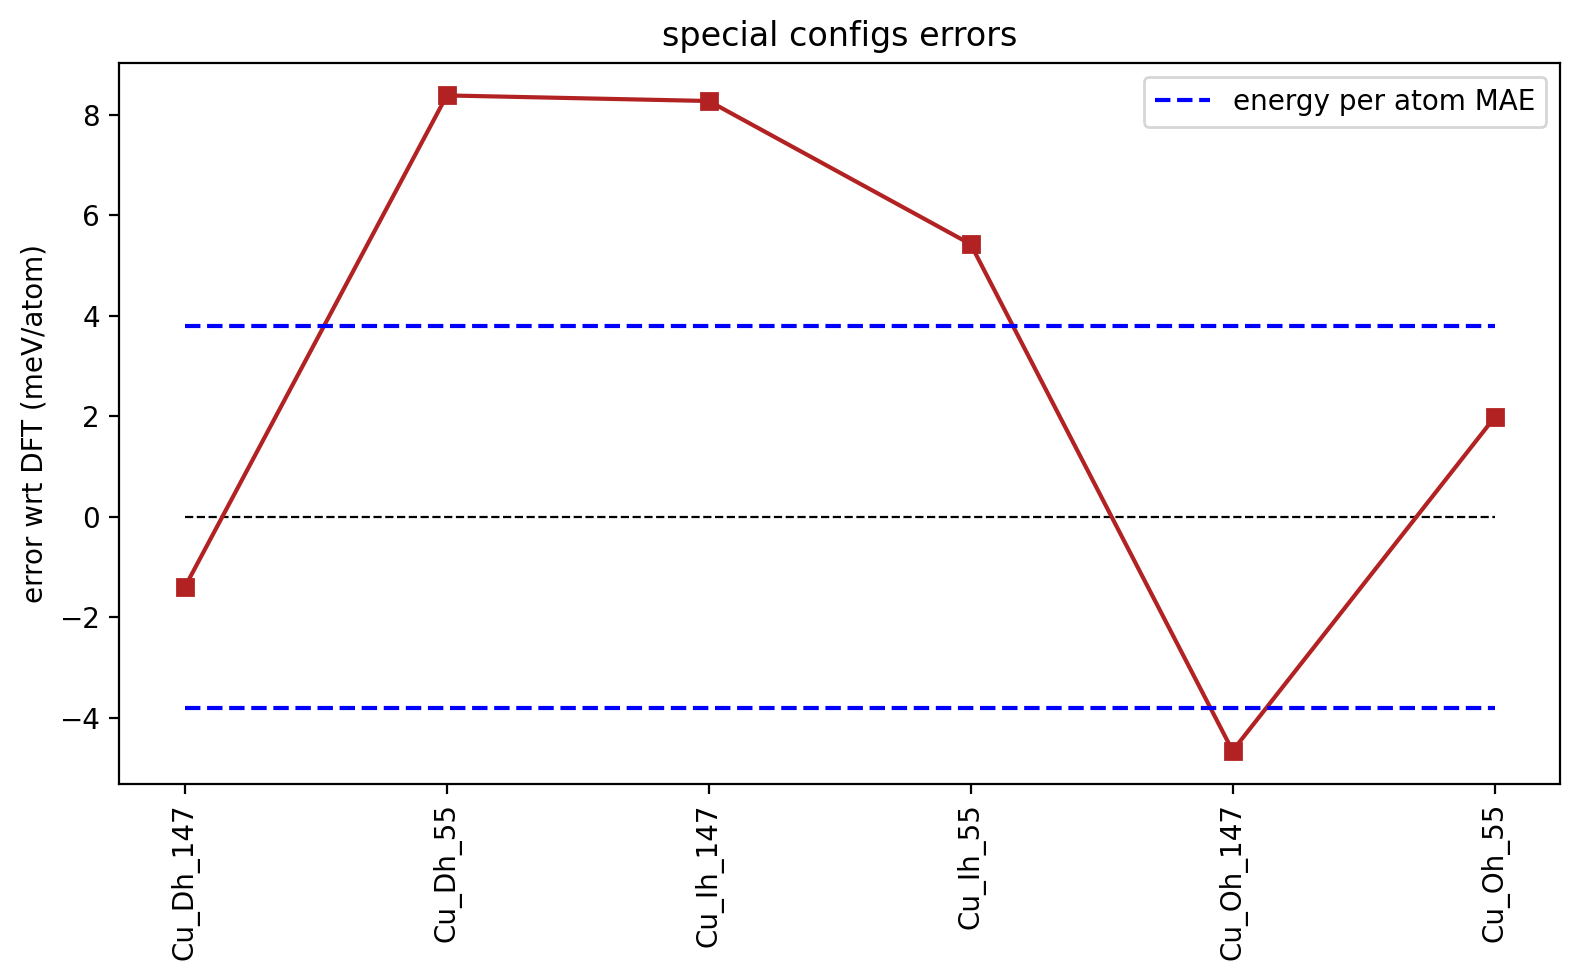

In [12]:
# error on specific configs
configs = []
for i, conf in enumerate(benchmarks.get("special_configs").keys()):
    try:
        name = conf.strip('_relax.pwo')
    except:
        name = str(i)
    configs.append(name)

#plot per atom error
labels = configs
x = np.arange(len(labels))

plt.figure(dpi=200, figsize=(8,5))
plt.title(f'special configs errors')
plt.hlines(0,  min(x), max(x), linestyles='--', color='k', lw=0.8)


y = 1000*np.array([ benchmarks.get("special_configs").get(key).get('energy_per_atom_error') for key in benchmarks.get("special_configs").keys() ])
            
plt.plot(x,  y, alpha=1., color='firebrick', marker='s')
mae = 1000*benchmarks.get(testset_file).get('energy_per_atom').get('mae')
plt.hlines([-mae, mae],0,len(labels)-1, linestyles='--', colors='b', label='energy per atom MAE')
plt.legend()
plt.xlabel("")
plt.xticks(x, labels, rotation=90.)
plt.ylabel("error wrt DFT (meV/atom)")
plt.tight_layout()

Phonon dispersion curves of the potential VS DFT reference - broken atm...

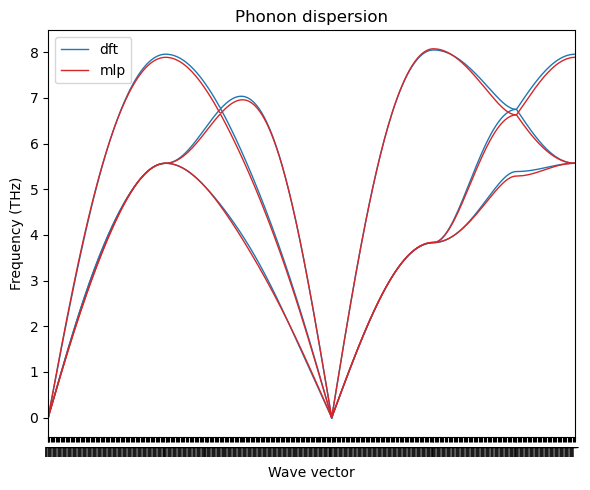

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import yaml


def load_band_yaml(filename):
    with open(filename, 'r') as f:
        data = yaml.safe_load(f)

    labels        = []
    label_points  = []
    distances     = []
    frequencies   = []

    npath = 0
    for segment in data['phonon']:
        q_points = segment['q-points'] if 'q-points' in segment else [segment]
        for q in q_points:
            distances.append(q['distance'])
            frequencies.append(q['band'])  # list of {frequency: ...}

        # Collect high-symmetry point labels at segment boundaries
        first = q_points[0]
        last  = q_points[-1]

        if npath == 0:
            labels.append(first.get('label', ''))
            label_points.append(first['distance'])

        labels.append(last.get('label', ''))
        label_points.append(last['distance'])
        npath += 1

    distances   = np.array(distances)
    # Shape: (n_qpoints, n_bands)
    frequencies = np.array([[b['frequency'] for b in q] for q in frequencies])

    return distances, frequencies, labels, label_points


def plot_dispersions(filenames, colors=None, labels=None, output=None):
    if colors is None:
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    if labels is None:
        labels = [f.replace('.yaml', '') for f in filenames]

    fig, ax = plt.subplots(figsize=(6, 5))

    ref_label_points = None
    ref_labels       = None

    for idx, filename in enumerate(filenames):
        distances, frequencies, sym_labels, label_points = load_band_yaml(filename)

        if ref_label_points is None:
            ref_label_points = label_points
            ref_labels       = sym_labels

        color = colors[idx % len(colors)]
        for band in range(frequencies.shape[1]):
            ax.plot(
                distances,
                frequencies[:, band],
                color=color,
                linewidth=1.0,
                label=labels[idx] if band == 0 else None,  # one legend entry per dataset
            )

    # Vertical lines and x-tick labels at high-symmetry points
    # for x, lbl in zip(ref_label_points, ref_labels):
    #     ax.axvline(x=x, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    ax.set_xticks(ref_label_points)
    ax.set_xticklabels([l if l else '$\\Gamma$' for l in ref_labels])
    ax.set_xlim(distances[0], distances[-1])
    #ax.axhline(y=0, color='black', linewidth=0.5, linestyle=':')
    ax.set_xlabel('Wave vector')
    ax.set_ylabel('Frequency (THz)')
    ax.set_title('Phonon dispersion')
    ax.legend()
    fig.tight_layout()

    if output:
        fig.savefig(output, dpi=300)
        print(f"Saved to {output}")
    else:
        plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
plot_dispersions(
    filenames=['/Users/ginardi/Desktop/science/55Ry/reference_data/Cu/tight_thresh/band.yaml', folder+'bands_mlp.yaml'],
    colors=['tab:blue', 'tab:red'],
    labels=['dft', 'mlp'],
    output=None,   # set to None to show interactively
)

Do this with mlputils

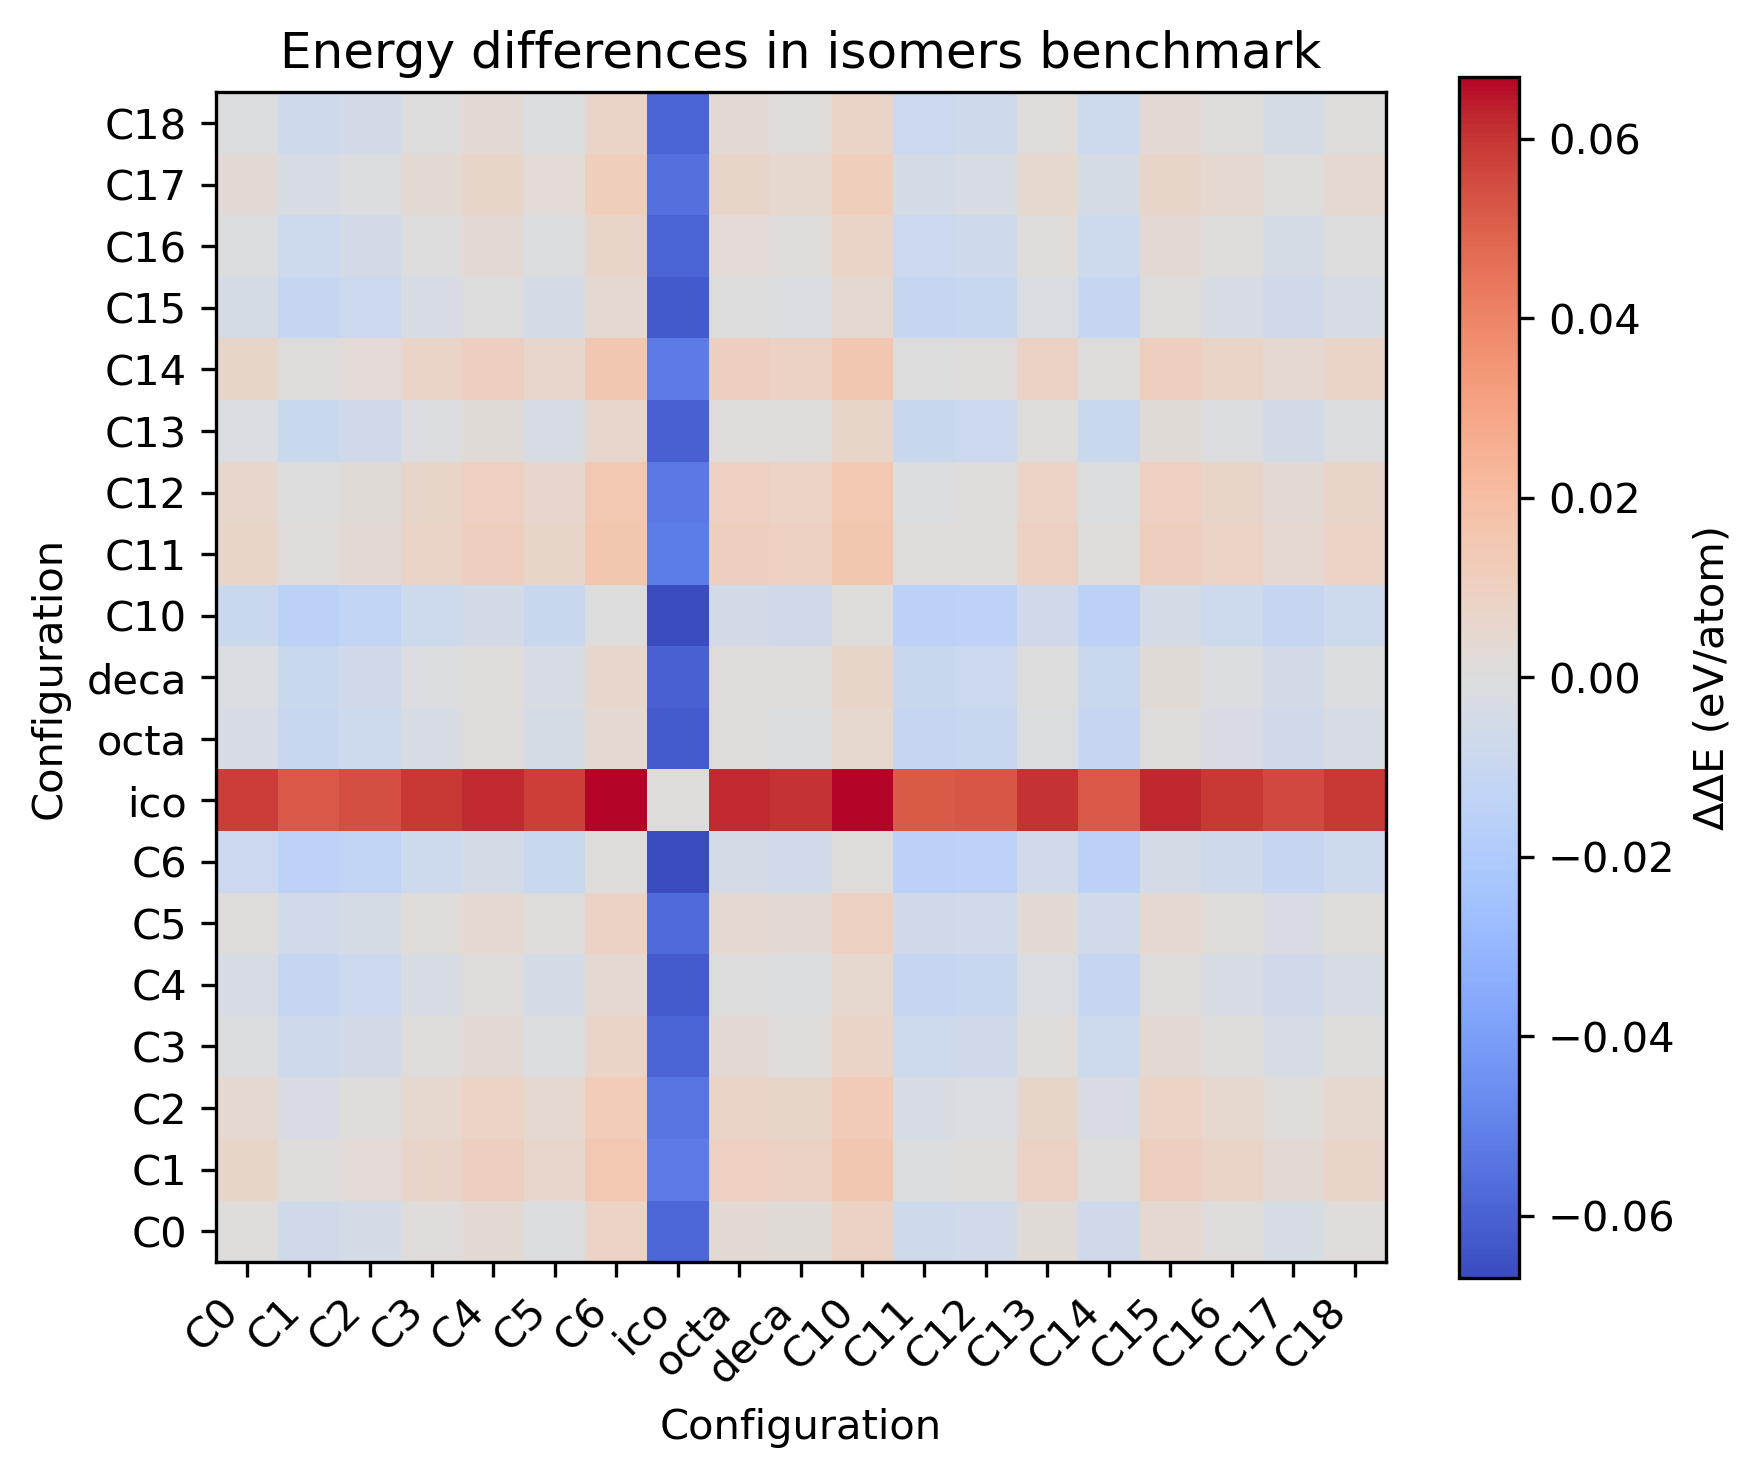

In [12]:
# run from local folder
# from mlputils.benchmark import make_energy_differences_matrix, get_calc

# with open('/Users/ginardi/Desktop/science/55Ry/Cu/Cu_benchmark_setup.yaml', 'r') as f:
#     bm_setup = yaml.safe_load(f)

# isomers_file = '/Users/ginardi/Desktop/science/isomers/download/Cu_55_isomers_dft.xyz'

# calc = get_calc(bm_setup)

# mat, ref, mod = make_energy_differences_matrix(calc, bm_setup.get('E_iso'), isomers_file)
diffs = np.loadtxt(folder+'diff_in_diff.dat')

diffs /= 55. #normalize to energy per atom

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

im = ax.imshow(diffs, cmap='coolwarm', origin='lower')

# custom labels
labels = [f'C{i}' for i in range(len(diffs))]
labels[7] = 'ico'
labels[8] = 'octa'
labels[9] = 'deca'

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

ax.set_xlabel('Configuration')
ax.set_ylabel('Configuration')

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('ΔΔE (eV/atom)')

plt.title('Energy differences in isomers benchmark')

plt.tight_layout()
plt.show()

In [16]:
mean = np.mean(diffs)
mae  = np.mean(np.abs(diffs))
std  = np.std(diffs)

print(mean, mae, std)

0.0 0.010530360150858835 0.01954284621336635


Do this with mlputils

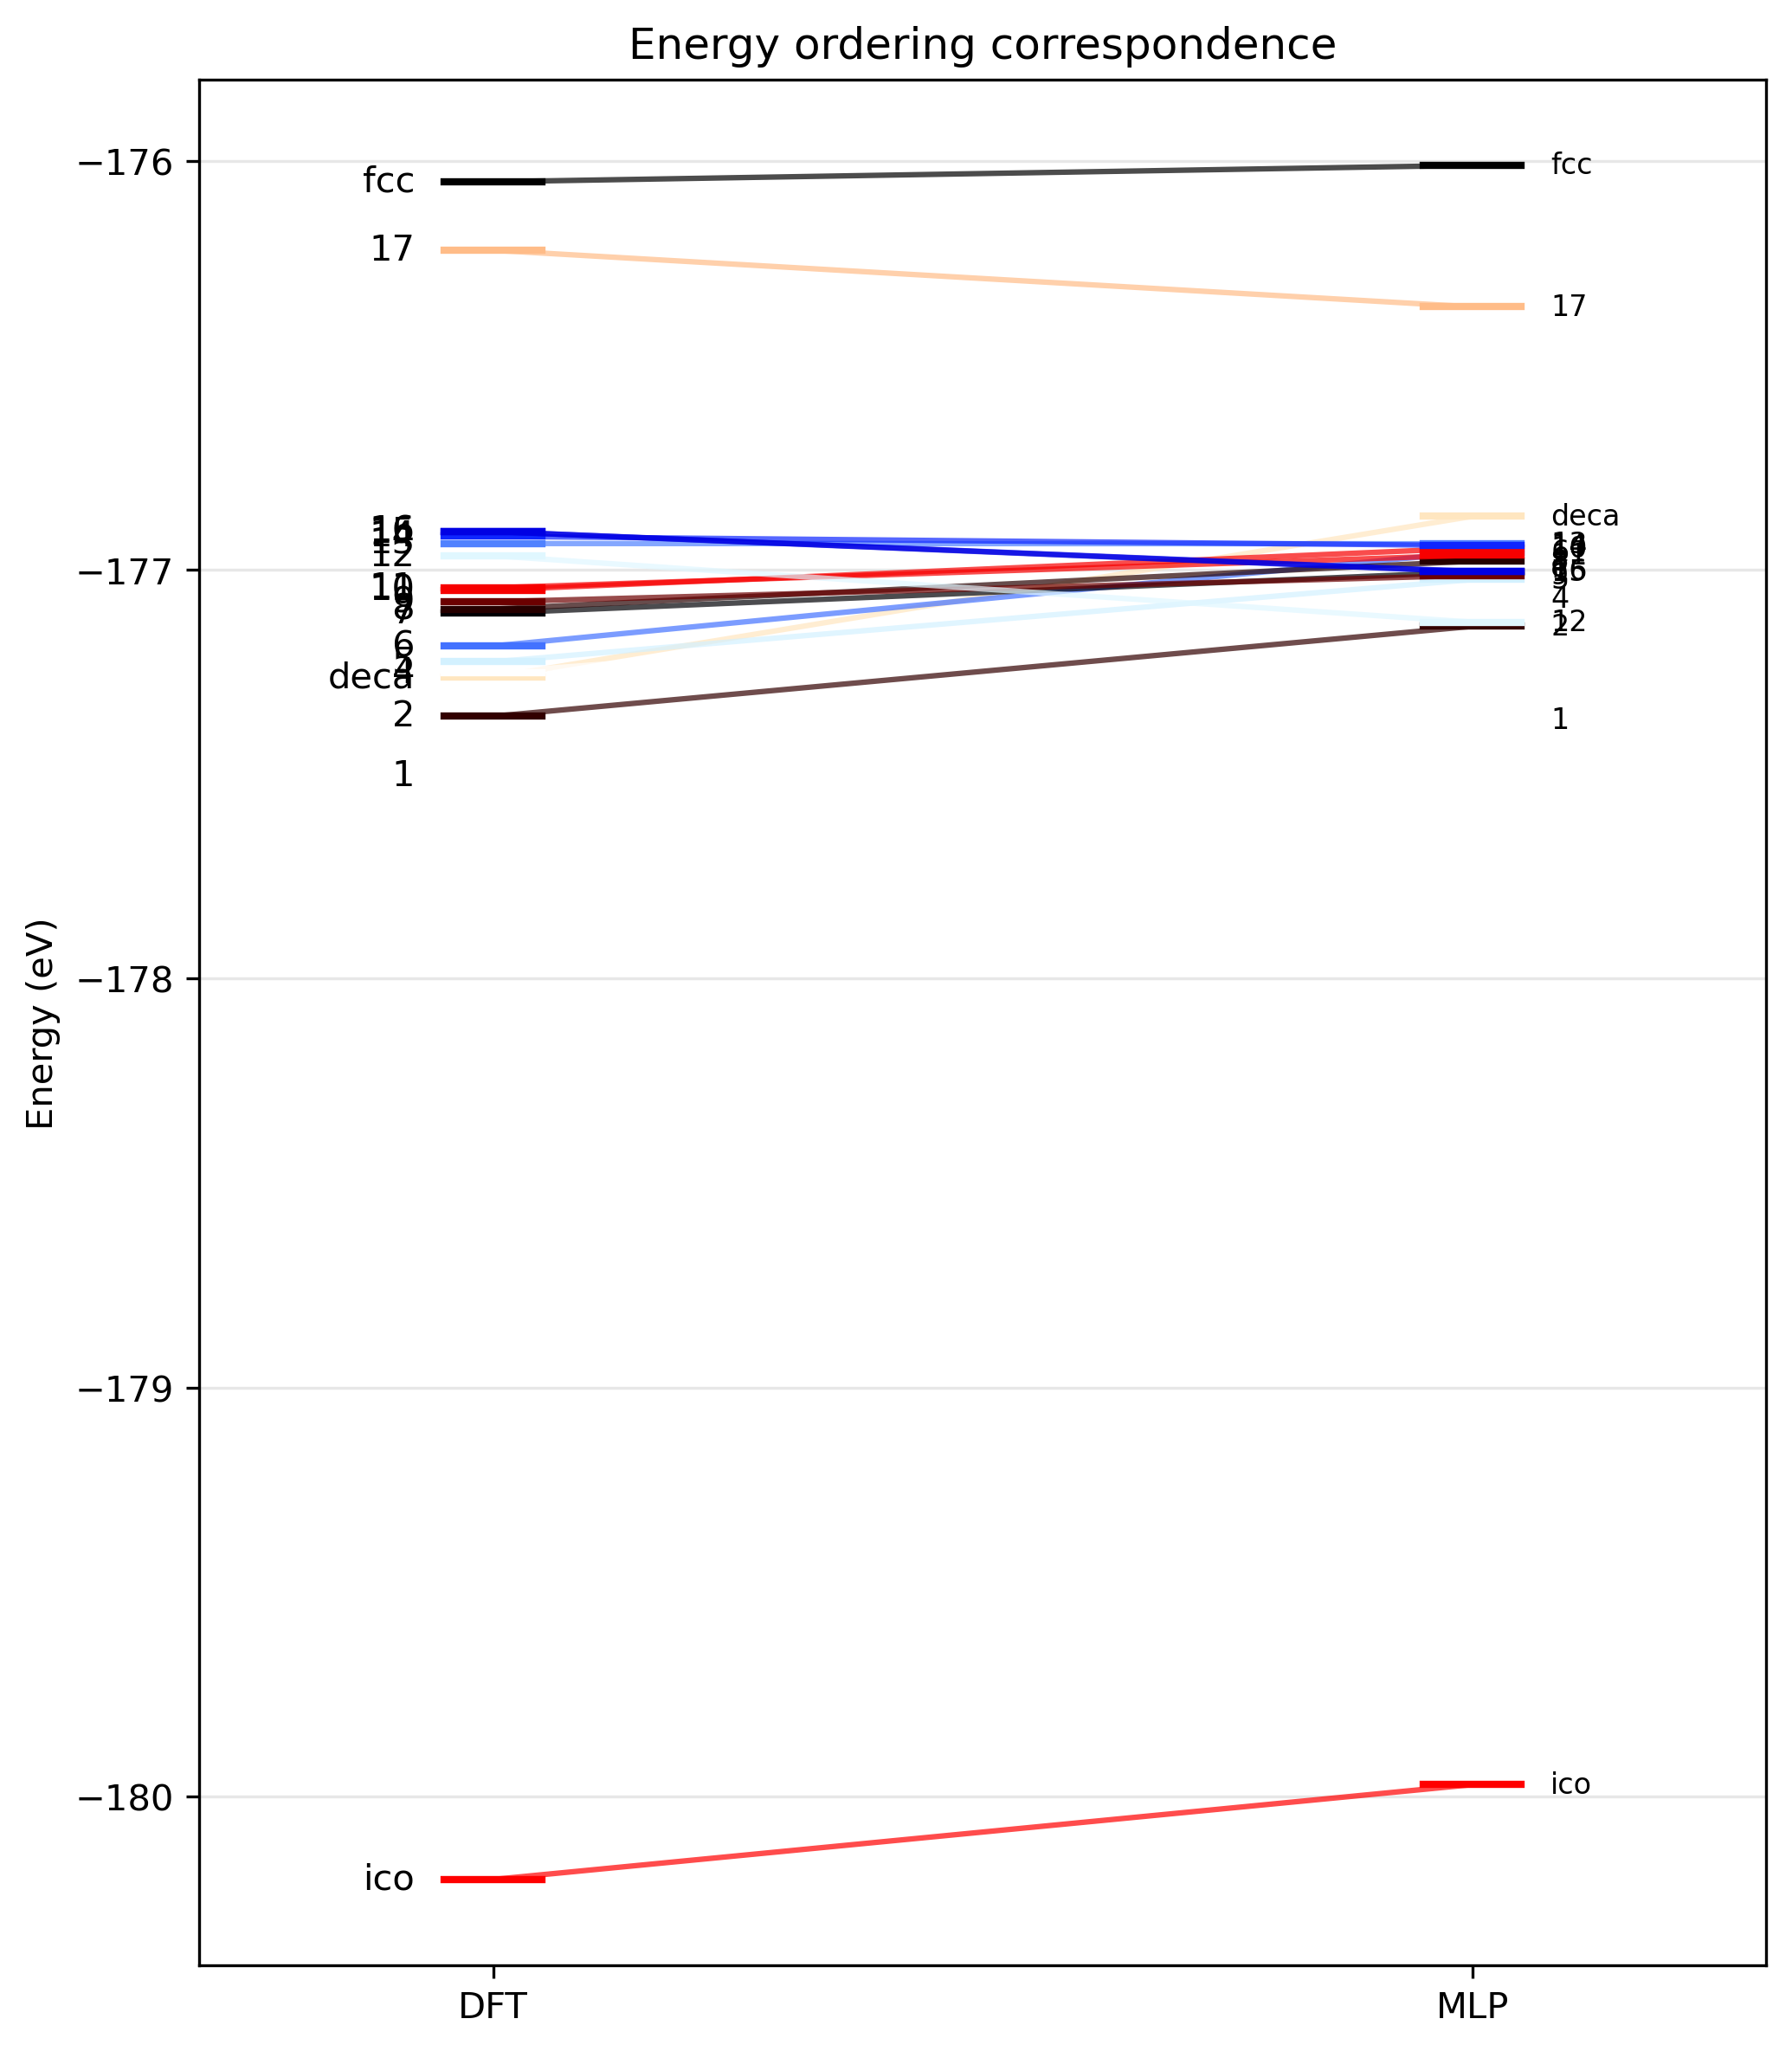

41 inversions found


In [ ]:
import matplotlib.colors as mcolors

#and make excess energy
#re-do this with mlputils and correct
iso_folder = '/Users/ginardi/Desktop/science/isomers/relax-leonardo/extracted_data'
iso_file = f'{iso_folder}/{element}55_relaxed_sorted.xyz'

labels = ['ico', '1', '2', 'deca', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', 'fcc']

ref_ene, calc_ene, inversions = energy_levels_crossings(iso_file, calc)


def plot_energy_correspondence(
    energies_A,
    energies_B,
    labels=None,
    left_label='A',
    right_label='B'
):

    energies_A = np.asarray(energies_A)
    energies_B = np.asarray(energies_B)

    if len(energies_A) != len(energies_B):
        raise ValueError("Arrays must have same length")

    n = len(energies_A)

    fig, ax = plt.subplots(figsize=(7, 8), dpi=300)

    x_left = 0
    x_right = 1

    cmap = plt.get_cmap('prism')
    norm = mcolors.Normalize(vmin=energies_A.min(), vmax=energies_A.max())

    # 2. get a color for any energy value
    colors = [cmap(norm(e)) for e in energies_A]

    for i, (ea, eb, c) in enumerate(zip(energies_A, energies_B, colors)):

        # left energy level
        ax.plot(
            [x_left - 0.05, x_left + 0.05],
            [ea, ea],
            lw=2,
            color=c
        )

        # right energy level
        ax.plot(
            [x_right - 0.05, x_right + 0.05],
            [eb, eb],
            lw=2,
            color=c
        )

        # connecting line
        ax.plot(
            [x_left, x_right],
            [ea, eb],
            alpha=0.7,
            color=c
        )

        # labels
        if labels is not None:

            # left labels
            ax.text(
                x_left - 0.08,
                ea,
                labels[i],
                ha='right',
                va='center',
                fontsize=10
            )

            # right labels
            ax.text(
                x_right + 0.08,
                eb,
                labels[i],
                ha='left',
                va='center',
                fontsize=8
            )

    ax.set_xlim(-0.3, 1.3)

    ax.set_xticks([x_left, x_right])
    ax.set_xticklabels([left_label, right_label])

    ax.set_ylabel('Energy (eV)')
    ax.set_title('Energy ordering correspondence')

    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()


#ref_ene = np.loadtxt(folder+'ref_energies_isomers.dat')
#mod_ene = np.loadtxt(folder+'mod_energies_isomers.dat')

ref_ene_no_iso = ref_ene - 55*-1661.4804019

plot_energy_correspondence(ref_ene_no_iso, calc_ene, labels, 'DFT', 'MLP')

print(inversions, 'inversions found')